# 🧠 Phase 1 — MRI Preprocessing Pipeline
## Yale Brain Metastases Longitudinal Dataset

**Date**: March 10, 2026  
**Environment**: `datapre` (Python 3.11, itk-elastix 0.24, SimpleITK 2.5.3)  
**GPU**: MX110 present but not usable (2GB VRAM + driver mismatch) → **CPU-optimized**

---

## ❓ What Has Already Been Done by Yale (Don't Repeat)

| Step | Status | Evidence |
|------|--------|----------|
| **Skull stripping (HD-BET)** | ✅ **ALREADY DONE** | Dataset paper + 91% zero voxels in NIfTIs |
| **N4 Bias field correction** | ✅ **SKIP** | Marginal value after HD-BET; adds ~3 min/volume on CPU |
| **Anonymization** | ✅ **ALREADY DONE** | Patient IDs are de-identified |

## ✅ What We Still Need To Do

| Step | Why | Tool |
|------|-----|------|
| **Intra-visit co-registration** | PRE/POST/T2/FLAIR are acquired separately — different FOV, position, shape | `itk-elastix` |
| **Resampling to 1mm³ isotropic** | Scans are 2D clinical (e.g. 0.72×0.72×5mm) — deep learning needs uniform voxel size | `SimpleITK` |
| **Intensity normalization** | MRI has no absolute scale (unlike CT HU) — z-score per volume stabilizes training | `numpy` |

---

## 🔄 Pipeline Flow (Per Visit)

```
Raw NIfTI (e.g. 256×320×32, voxel=0.72×0.72×5mm)
    │
    ▼
Step 1: Rigid Registration  ← align POST/T2/FLAIR → PRE space
    │
    ▼
Step 2: Resample to 1×1×1mm  ← uniform voxel grid for deep learning
    │
    ▼
Step 3: Intensity Normalization  ← z-score per volume (clip 1-99th pct)
    │
    ▼
Processed NIfTI → Data/processed/{patient_id}/{visit_date}/{modality}.nii.gz
```

---
## Section 1 — Import Libraries & Environment Check

In [3]:
import os
import sys
import time
import json
import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches

import nibabel as nib
import SimpleITK as sitk
import itk

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# Display settings for medical image visualization
# ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "figure.titlesize": 14,
    "axes.titlesize": 11,
    "font.family": "monospace",
})

# ─────────────────────────────────────────────
# CPU thread configuration
# ─────────────────────────────────────────────
N_THREADS = max(1, os.cpu_count() - 1)   # leave 1 core free for the OS
sitk.ProcessObject.SetGlobalDefaultNumberOfThreads(N_THREADS)

print("=" * 60)
print(f"  Python        : {sys.version.split()[0]}")
print(f"  Platform      : {platform.platform()}")
print(f"  CPU cores     : {os.cpu_count()} total → using {N_THREADS}")
print(f"  SimpleITK     : {sitk.Version.VersionString()}")
print(f"  ITK           : {itk.__version__}")
print(f"  nibabel       : {nib.__version__}")
print(f"  numpy         : {np.__version__}")
print("=" * 60)

# GPU status (informational — we run on CPU)
try:
    import torch
    gpu = torch.cuda.is_available()
    print(f"  PyTorch GPU   : {'✅ ' + torch.cuda.get_device_name(0) if gpu else '❌ None (CPU mode)'}")
except ImportError:
    print("  PyTorch       : not installed")
print("=" * 60)

  Python        : 3.11.14
  Platform      : Linux-6.8.0-101-generic-x86_64-with-glibc2.39
  CPU cores     : 8 total → using 7
  SimpleITK     : 2.5.3
  ITK           : 5.4.5
  nibabel       : 5.3.3
  numpy         : 1.26.4
  PyTorch GPU   : ❌ None (CPU mode)


---
## Section 2 — Configuration & Paths

All paths defined once here. Every downstream cell reads from these variables — no hardcoded paths anywhere.

> **Idempotency**: If `{OUTPUT_DIR}/{patient_id}/{visit_date}/{mod}.nii.gz` already exists, the pipeline skips that visit. Safe to re-run after interruption.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# ROOT PATHS
# ─────────────────────────────────────────────────────────────────────────────
BASE_DIR    = Path("/home/moamed/canada_me/explainable_diseas/implementation")
RAW_DIR = Path("/media/moamed/Data/Yale-Brain-Mets-Longitudinal")

# ─── OUTPUT → 1TB HDD (575 GB free at /media/moamed/Data) ───────────────────
OUTPUT_DIR  = Path("/media/moamed/Data/yale-processed")
LOG_PATH    = BASE_DIR / "outputs" / "preprocessing_log.csv"
INVENTORY   = BASE_DIR / "outputs" / "data_inventory.csv"
SPLITS      = BASE_DIR / "outputs" / "splits.json"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output root  : {OUTPUT_DIR}  (exists: {OUTPUT_DIR.exists()})")

# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESSING SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
TARGET_SPACING  = (1.0, 1.0, 1.0)
MODALITIES      = ["PRE", "POST", "T2", "FLAIR"]
FIXED_MOD       = "PRE"
CLIP_PERCENTILE = (1.0, 99.0)
INTERP_LINEAR   = sitk.sitkLinear
INTERP_NN       = sitk.sitkNearestNeighbor

TEST_PATIENT = "YG_01M98EKKAR50"
TEST_VISIT   = "2016-11-13"

df_inv = pd.read_csv(INVENTORY)
row = df_inv[(df_inv["patient_id"] == TEST_PATIENT) &
             (df_inv["visit_date"] == TEST_VISIT)].iloc[0]

RAW_PATHS = {
    "PRE"  : Path(row["path_PRE"]),
    "POST" : Path(row["path_POST"]),
    "T2"   : Path(row["path_T2"]),
    "FLAIR": Path(row["path_FLAIR"]),
}

print(f"Test patient : {TEST_PATIENT}")
print(f"Test visit   : {TEST_VISIT}")
print(f"Usability    : {row['training_usability']}")
print()
for mod, p in RAW_PATHS.items():
    img = nib.load(str(p))
    print(f"  {mod:5s}: shape={img.shape}  voxel_mm={tuple(round(float(x),3) for x in img.header.get_zooms()[:3])}")


Output root  : /media/moamed/Data/yale-processed  (exists: True)
Test patient : YG_01M98EKKAR50
Test visit   : 2016-11-13
Usability    : FULL

  PRE  : shape=(256, 320, 32)  voxel_mm=(0.719, 0.719, 5.0)
  POST : shape=(272, 320, 32)  voxel_mm=(0.719, 0.719, 5.0)
  T2   : shape=(320, 320, 32)  voxel_mm=(0.719, 0.719, 5.0)
  FLAIR: shape=(320, 320, 32)  voxel_mm=(0.719, 0.719, 5.0)
  T2   : shape=(320, 320, 32)  voxel_mm=(0.719, 0.719, 5.0)
  FLAIR: shape=(320, 320, 32)  voxel_mm=(0.719, 0.719, 5.0)


---
## Section 3 — Load Raw Data & Visualize Baseline

Before touching any data, we always look at it first.

**Why?**  
- Confirms file paths are correct  
- Lets you visually detect obvious issues (black slices, wrong orientation, ghost artifacts)  
- Establishes the "before" reference for every subsequent step

**What you'll see:**  
- 4 modalities × 3 views (axial, coronal, sagittal) = 12 slice panels  
- Shape and voxel size printed per modality — notice **different shapes** for different modalities in the same visit (that's exactly why we need co-registration)

Loading raw volumes:
  PRE  : size=(256, 320, 32)  spacing=(0.719, 0.719, 5.000) mm
  PRE  : size=(256, 320, 32)  spacing=(0.719, 0.719, 5.000) mm
  POST : size=(272, 320, 32)  spacing=(0.719, 0.719, 5.000) mm
  T2   : size=(320, 320, 32)  spacing=(0.719, 0.719, 5.000) mm
  FLAIR: size=(320, 320, 32)  spacing=(0.719, 0.719, 5.000) mm
  POST : size=(272, 320, 32)  spacing=(0.719, 0.719, 5.000) mm
  T2   : size=(320, 320, 32)  spacing=(0.719, 0.719, 5.000) mm
  FLAIR: size=(320, 320, 32)  spacing=(0.719, 0.719, 5.000) mm


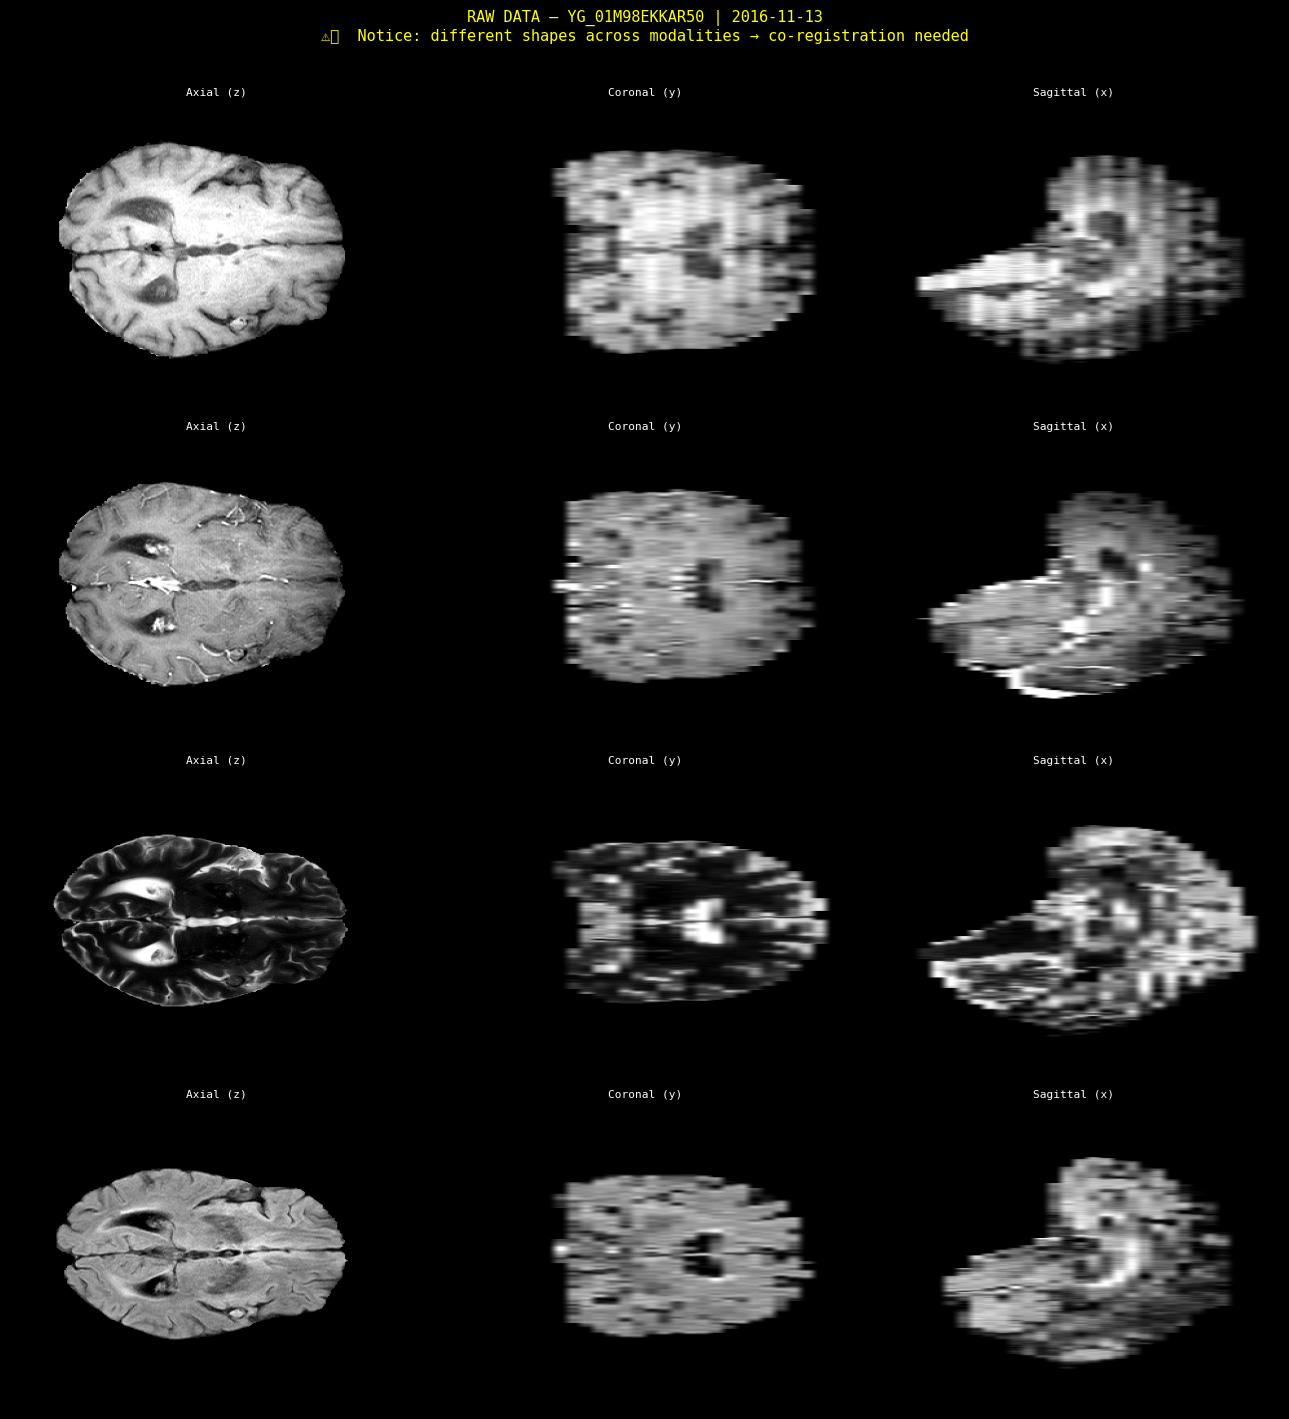


✅ Raw data loaded and visualized.


In [5]:
def load_sitk(path: Path) -> sitk.Image:
    """Load a NIfTI file as a SimpleITK image."""
    return sitk.ReadImage(str(path), sitk.sitkFloat32)

def sitk_to_numpy(img: sitk.Image) -> np.ndarray:
    """Convert SimpleITK image to numpy array (z, y, x)."""
    return sitk.GetArrayFromImage(img)  # returns (z, y, x)

def show_three_views(data: np.ndarray, title: str, ax_row, cmap="gray", vmin=None, vmax=None):
    """Plot axial / coronal / sagittal middle slice in given axes row."""
    z, y, x = data.shape
    slices = [
        ("Axial (z)",    data[z//2, :, :]),
        ("Coronal (y)",  data[:, y//2, :]),
        ("Sagittal (x)", data[:, :, x//2]),
    ]
    p1, p99 = np.percentile(data[data > 0], [1, 99]) if data.max() > 0 else (0, 1)
    vmin = vmin if vmin is not None else p1
    vmax = vmax if vmax is not None else p99
    for ax, (label, sl) in zip(ax_row, slices):
        ax.imshow(np.rot90(sl), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(label, fontsize=8, color="white", pad=2)
        ax.axis("off")
    ax_row[0].set_ylabel(title, color="white", fontsize=9, rotation=90, labelpad=4)

# ─────────────────────────────────────────────────────────────────────────────
# Load all 4 raw modalities
# ─────────────────────────────────────────────────────────────────────────────
raw_sitk = {}
raw_np   = {}
print("Loading raw volumes:")
for mod in MODALITIES:
    img = load_sitk(RAW_PATHS[mod])
    raw_sitk[mod] = img
    raw_np[mod]   = sitk_to_numpy(img)
    sp = img.GetSpacing()
    sz = img.GetSize()
    print(f"  {mod:5s}: size={sz}  spacing=({sp[0]:.3f}, {sp[1]:.3f}, {sp[2]:.3f}) mm")

# ─────────────────────────────────────────────────────────────────────────────
# Visualize: 4 modalities × 3 views
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(13, 14))
fig.suptitle(
    f"RAW DATA — {TEST_PATIENT} | {TEST_VISIT}\n"
    f"⚠️  Notice: different shapes across modalities → co-registration needed",
    fontsize=11, color="yellow", y=1.01
)
for i, mod in enumerate(MODALITIES):
    sp = raw_sitk[mod].GetSpacing()
    sz = raw_sitk[mod].GetSize()
    label = f"{mod}\n{sz[0]}×{sz[1]}×{sz[2]}\n{sp[0]:.2f}×{sp[1]:.2f}×{sp[2]:.2f}mm"
    show_three_views(raw_np[mod], label, axes[i])

plt.tight_layout()
plt.savefig(str(BASE_DIR / "outputs" / "eda" / "figures" / "preproc_00_raw_data.png"),
            dpi=100, bbox_inches="tight", facecolor="black")
plt.show()
print("\n✅ Raw data loaded and visualized.")

---
## Section 4 — Step 1: Intra-Visit Co-Registration

### Why Is This Needed?

In a single clinical MRI visit, the scanner acquires each sequence (T1, T1c, T2, FLAIR) as a **separate scan**. Between sequences:
- The patient moves slightly (breathing, repositioning)
- Each sequence has a **different field of view** (FOV) and **different matrix size**
- The scanner origin/orientation headers may differ

**Result**: If you stack PRE + POST + T2 + FLAIR as a 4-channel volume, the channels won't overlap — a voxel at position [i,j,k] in the PRE image does NOT correspond to the same brain location in the POST image.

**For deep learning**: A 4-channel CNN expects channel [0] and channel [1] at position [i,j,k] to represent the **same voxel in 3D space**. Without registration, the model learns garbage correlations.

### What We Do

- **Fixed image**: `PRE` (T1 pre-contrast) — chosen as reference because it has the most consistent acquisition and is always present in high-quality visits
- **Moving images**: `POST`, `T2`, `FLAIR` — rigidly aligned to PRE
- **Method**: Rigid registration (6 DOF: 3 translation + 3 rotation) using `itk-elastix`
  - Rigid is correct here: brain doesn't deform within a visit, just translates/rotates slightly
  - Affine would be overkill (and could introduce fake deformations)

### Why Not BraTS Toolkit / HD-BET Registration?

- BraTS Toolkit registration uses the same elastix under the hood
- Skull stripping is **already done** in Yale
- We avoid adding another heavy dependency when `itk-elastix` is already in `datapre`

### Runtime Estimate

~15–30 seconds per visit on CPU (4 cores). For 11,877 visits: ~70–100 hours total → launch as overnight batch.

In [6]:
def register_to_fixed(fixed_sitk: sitk.Image, moving_sitk: sitk.Image,
                      n_threads: int = N_THREADS) -> sitk.Image:
    """
    Rigid registration of moving_sitk → fixed_sitk space using itk-elastix.

    Steps:
      1. Cast both images to ITK float type
      2. Build elastix parameter map (rigid = translation + rotation only)
      3. Run elastix registration (CPU, n_threads cores)
      4. Return registered image in fixed image space (same size/spacing as fixed)

    Returns
    -------
    sitk.Image : moving image registered to fixed space

    Note: WriteResultImage must be 'true' for GetOutput() to return the registered
    image data. When 'false', elastix skips writing the result image to memory and
    GetOutput() returns None. We rely on GetOutput() here, so it must be 'true'.
    """
    # Convert SimpleITK → ITK (both are wrappers, share the same pixel buffer)
    fixed_itk  = itk.GetImageFromArray(sitk.GetArrayFromImage(fixed_sitk).astype(np.float32))
    moving_itk = itk.GetImageFromArray(sitk.GetArrayFromImage(moving_sitk).astype(np.float32))

    # Copy spatial metadata (spacing, origin, direction)
    fixed_itk.SetSpacing(fixed_sitk.GetSpacing())
    fixed_itk.SetOrigin(fixed_sitk.GetOrigin())
    moving_itk.SetSpacing(moving_sitk.GetSpacing())
    moving_itk.SetOrigin(moving_sitk.GetOrigin())

    # Build rigid elastix parameter map
    param_obj = itk.ParameterObject.New()
    rigid_map = param_obj.GetDefaultParameterMap("rigid")

    # Key settings for brain MRI rigid registration
    rigid_map["NumberOfResolutions"]            = ["4"]
    rigid_map["MaximumNumberOfIterations"]      = ["500"]
    rigid_map["NumberOfSpatialSamples"]         = ["4096"]
    rigid_map["Metric"]                         = ["AdvancedMattesMutualInformation"]
    rigid_map["Interpolator"]                   = ["LinearInterpolator"]
    rigid_map["ResampleInterpolator"]           = ["FinalLinearInterpolator"]
    rigid_map["BSplineInterpolationOrder"]      = ["1"]
    rigid_map["NumberOfThreads"]                = [str(n_threads)]
    rigid_map["WriteResultImage"]               = ["true"]   # MUST be true for GetOutput()
    rigid_map["ResultImagePixelType"]           = ["float"]

    param_obj.AddParameterMap(rigid_map)

    # Run registration
    elastix_obj = itk.ElastixRegistrationMethod.New(fixed_itk, moving_itk)
    elastix_obj.SetParameterObject(param_obj)
    elastix_obj.SetLogToConsole(False)
    elastix_obj.UpdateLargestPossibleRegion()

    result_itk = elastix_obj.GetOutput()

    # Convert back to SimpleITK
    result_np  = itk.GetArrayFromImage(result_itk).astype(np.float32)
    result_img = sitk.GetImageFromArray(result_np)
    result_img.CopyInformation(fixed_sitk)   # adopt fixed image's geometry exactly
    return result_img


# ─────────────────────────────────────────────────────────────────────────────
# Run registration: POST, T2, FLAIR → PRE space
# ─────────────────────────────────────────────────────────────────────────────
fixed_img = raw_sitk[FIXED_MOD]
registered_sitk = {FIXED_MOD: fixed_img}   # PRE stays as-is

print(f"Fixed image (reference): {FIXED_MOD}  {fixed_img.GetSize()} @ {fixed_img.GetSpacing()} mm")
print()

for mod in [m for m in MODALITIES if m != FIXED_MOD]:
    t0 = time.time()
    print(f"  Registering {mod} → {FIXED_MOD} ...", end=" ", flush=True)
    registered_sitk[mod] = register_to_fixed(fixed_img, raw_sitk[mod])
    elapsed = time.time() - t0
    print(f"✅  {elapsed:.1f}s   |  result size: {registered_sitk[mod].GetSize()}")

registered_np = {mod: sitk_to_numpy(img) for mod, img in registered_sitk.items()}
print("\nAll modalities registered to PRE space.")


Fixed image (reference): PRE  (256, 320, 32) @ (0.7187500596046448, 0.71875, 5.0) mm

  Registering POST → PRE ... ✅  33.1s   |  result size: (256, 320, 32)
  Registering T2 → PRE ... ✅  33.1s   |  result size: (256, 320, 32)
  Registering T2 → PRE ... ✅  3.3s   |  result size: (256, 320, 32)
  Registering FLAIR → PRE ... ✅  3.3s   |  result size: (256, 320, 32)
  Registering FLAIR → PRE ... ✅  3.2s   |  result size: (256, 320, 32)

All modalities registered to PRE space.
✅  3.2s   |  result size: (256, 320, 32)

All modalities registered to PRE space.


---
## 📊 Before & After — Registration

What to look for:
- **Before**: POST/T2/FLAIR have **different shapes** from PRE; slice at the same index shows a different part of the brain
- **After**: All modalities have the **same shape** as PRE; the same brain structure appears at the same pixel position
- **Difference map**: White pixels = misalignment. After registration, difference should be near zero in skull-stripped regions

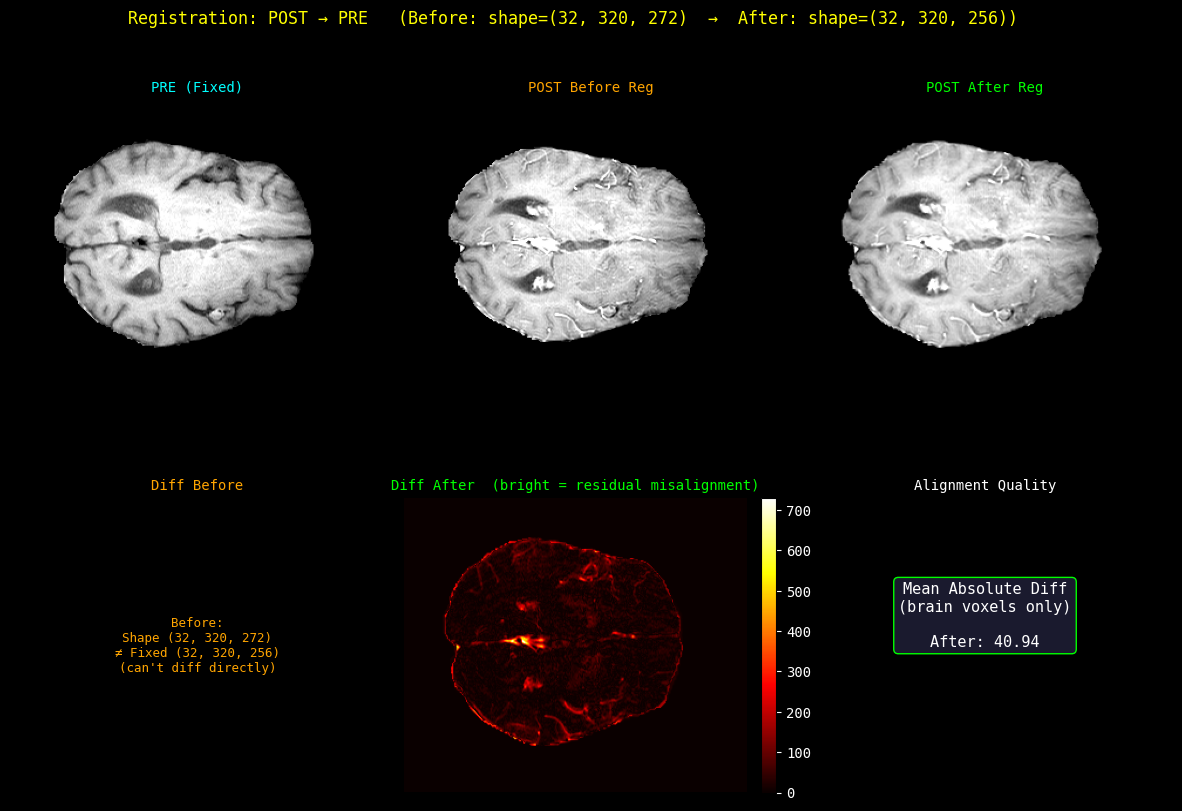

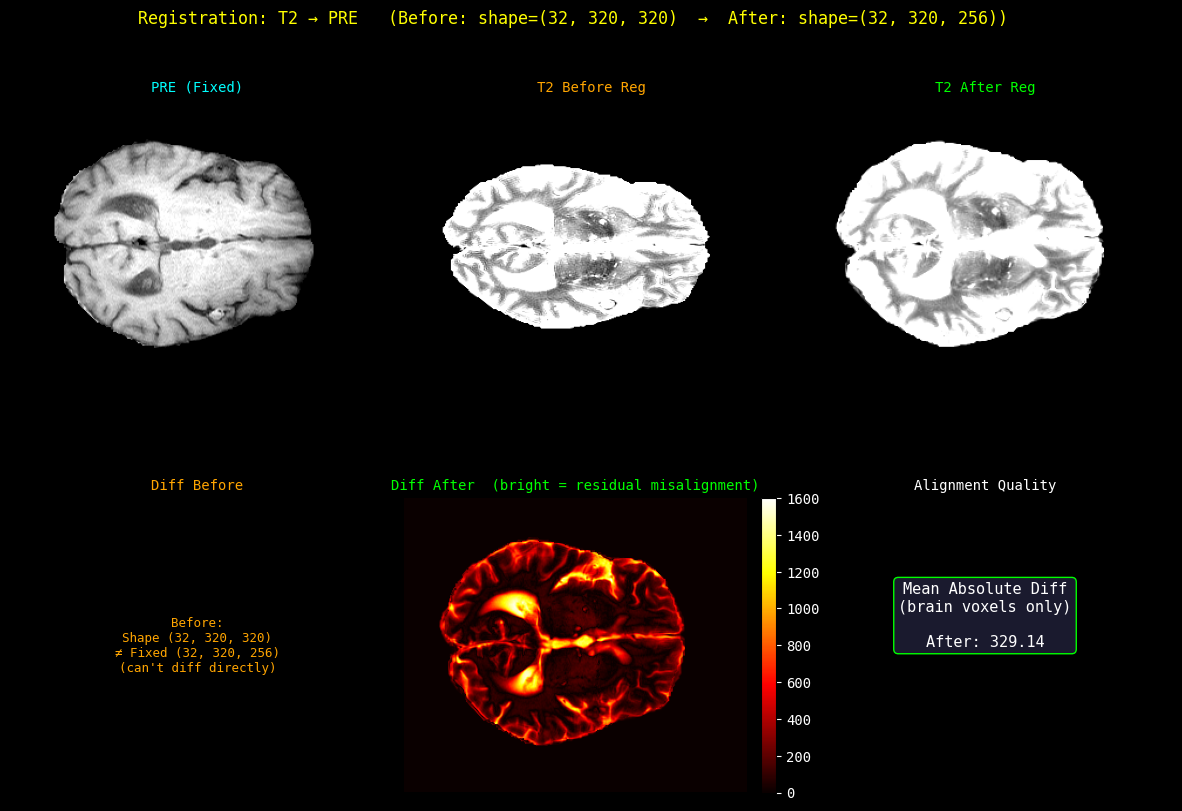

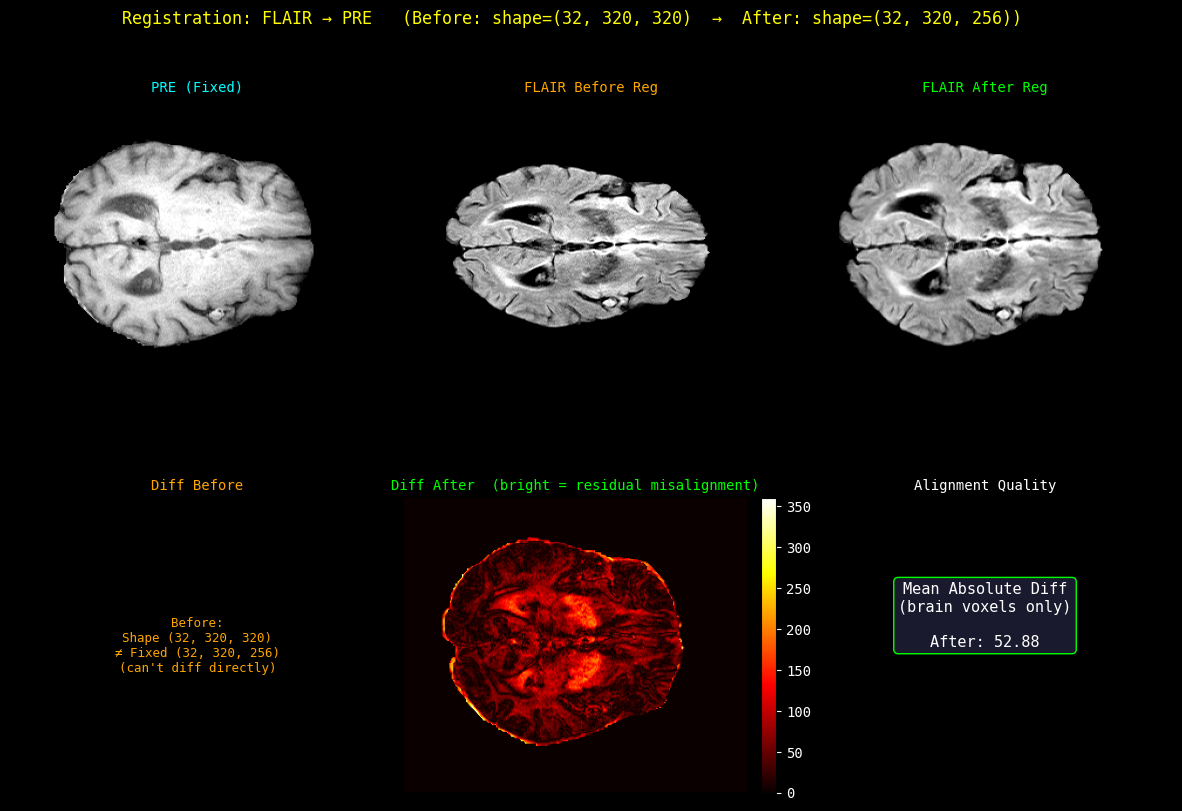

In [7]:
def plot_registration_before_after(fixed_np, raw_np_mod, reg_np_mod, mod_name, fixed_mod="PRE"):
    """
    3-column layout:
      Col 1: Fixed image (PRE) — the reference
      Col 2: Moving image BEFORE registration
      Col 3: Moving image AFTER registration
      Row 2: Difference maps (|fixed - moving|) before and after
    """
    fig = plt.figure(figsize=(15, 9))
    fig.patch.set_facecolor("black")
    fig.suptitle(
        f"Registration: {mod_name} → {fixed_mod}   "
        f"(Before: shape={raw_np_mod.shape}  →  After: shape={reg_np_mod.shape})",
        fontsize=12, color="yellow"
    )
    gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.05)

    # Use the middle axial slice
    z_fixed = fixed_np.shape[0] // 2

    # Normalise for display (use fixed image range as reference)
    p1, p99 = np.percentile(fixed_np[fixed_np > 0], [1, 99]) if fixed_np.max() > 0 else (0, 1)

    def get_axial(vol, z_idx):
        """Get axial slice; if vol has fewer slices use proportional index."""
        idx = min(z_idx, vol.shape[0] - 1)
        return np.rot90(vol[idx])

    fixed_sl   = get_axial(fixed_np,    z_fixed)
    before_sl  = get_axial(raw_np_mod,  z_fixed)   # may be different size — that's the point
    after_sl   = get_axial(reg_np_mod,  z_fixed)

    # Row 0: images
    for col, (sl, title, color) in enumerate([
        (fixed_sl,  f"{fixed_mod} (Fixed)",         "cyan"),
        (before_sl, f"{mod_name} Before Reg",       "orange"),
        (after_sl,  f"{mod_name} After Reg",        "lime"),
    ]):
        ax = fig.add_subplot(gs[0, col])
        ax.imshow(sl, cmap="gray", vmin=p1, vmax=p99, aspect="auto")
        ax.set_title(title, color=color, fontsize=10)
        ax.axis("off")

    # Row 1: difference maps (only where both images have the same shape)
    ax_before_diff = fig.add_subplot(gs[1, 0])
    ax_before_diff.set_facecolor("black")
    ax_before_diff.axis("off")
    ax_before_diff.text(0.5, 0.5,
        f"Before:\nShape {raw_np_mod.shape}\n≠ Fixed {fixed_np.shape}\n(can't diff directly)",
        ha="center", va="center", color="orange", fontsize=9,
        transform=ax_before_diff.transAxes)
    ax_before_diff.set_title("Diff Before", color="orange", fontsize=10)

    # After registration both are in fixed space → same shape → can diff
    ax_after_diff = fig.add_subplot(gs[1, 1])
    diff_after = np.abs(fixed_sl.astype(np.float32) - after_sl.astype(np.float32))
    ax_after_diff.imshow(diff_after, cmap="hot", aspect="auto", vmin=0, vmax=diff_after.max())
    ax_after_diff.set_title("Diff After  (bright = residual misalignment)", color="lime", fontsize=10)
    ax_after_diff.axis("off")
    fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(0, diff_after.max()), cmap="hot"),
                 ax=ax_after_diff, fraction=0.046, pad=0.04)

    # MAD metric
    ax_metric = fig.add_subplot(gs[1, 2])
    ax_metric.set_facecolor("black")
    ax_metric.axis("off")
    brain_mask = fixed_np > 0
    mad_after = np.mean(np.abs((fixed_np.astype(np.float32) -
                                reg_np_mod.astype(np.float32))[brain_mask]))
    ax_metric.text(0.5, 0.6,
        f"Mean Absolute Diff\n(brain voxels only)\n\nAfter: {mad_after:.2f}",
        ha="center", va="center", color="white", fontsize=11,
        transform=ax_metric.transAxes,
        bbox=dict(boxstyle="round", facecolor="#1a1a2e", edgecolor="lime"))
    ax_metric.set_title("Alignment Quality", color="white", fontsize=10)

    plt.savefig(str(BASE_DIR / "outputs" / "eda" / "figures" /
                    f"preproc_01_registration_{mod_name}.png"),
                dpi=100, bbox_inches="tight", facecolor="black")
    plt.show()


# Plot for each registered modality
for mod in [m for m in MODALITIES if m != FIXED_MOD]:
    plot_registration_before_after(
        fixed_np   = raw_np[FIXED_MOD],
        raw_np_mod = raw_np[mod],
        reg_np_mod = registered_np[mod],
        mod_name   = mod,
    )

---
## Section 5 — Step 2: Resample to 1mm³ Isotropic

### Why Is This Needed?

After registration, all modalities are in the same **coordinate space**, but the voxel grid is still anisotropic — e.g. `0.72 × 0.72 × 5.0 mm`. This means:

- The Z-direction has **7× fewer samples** than X/Y → CNNs get distorted features
- A `3×3×3` convolution kernel covers `0.72×0.72×5.0mm` of real brain tissue (a flat pancake, not a cube)
- Cross-patient comparison is invalid if one scan has 5mm slices and another has 1mm slices

**Target**: `1.0 × 1.0 × 1.0 mm` for every output volume.

### What Changes?

| Before | After |
|--------|-------|
| Shape: ~256×320×32 | Shape: ~184×230×160 (example) |
| Voxel: 0.72×0.72×5mm | Voxel: 1.0×1.0×1.0mm |
| Z slices: 32 (thick) | Z slices: ~160 (interpolated, isotropic) |

### Interpolation Method

- **Linear interpolation** for brain tissue intensities — smooth and accurate for continuous-valued MRI
- **Nearest-neighbor** would be used only for segmentation masks (preserves discrete labels)

### Runtime

~1–3 seconds per volume on CPU (SimpleITK is fast for this).

In [8]:
def resample_to_isotropic(img: sitk.Image,
                          target_spacing: tuple = TARGET_SPACING,
                          interpolator=INTERP_LINEAR) -> sitk.Image:
    """
    Resample a SimpleITK image to target_spacing (default 1×1×1 mm).

    Uses the physical extent of the image to compute the new output size,
    so no brain tissue is cropped — only the voxel grid changes.

    Parameters
    ----------
    img            : input SimpleITK image (float32)
    target_spacing : desired output spacing in mm (x, y, z)
    interpolator   : sitk interpolation method

    Returns
    -------
    sitk.Image : resampled image
    """
    orig_spacing = np.array(img.GetSpacing())        # (x, y, z) mm
    orig_size    = np.array(img.GetSize())            # (x, y, z) voxels

    # Compute new size to cover the same physical extent
    new_spacing  = np.array(target_spacing, dtype=np.float64)
    new_size     = np.round(orig_size * orig_spacing / new_spacing).astype(int)
    new_size     = [int(s) for s in new_size]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputOrigin(img.GetOrigin())
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetInterpolator(interpolator)
    resampler.SetDefaultPixelValue(0.0)
    resampler.SetOutputPixelType(sitk.sitkFloat32)

    return resampler.Execute(img)


# ─────────────────────────────────────────────────────────────────────────────
# Resample all registered modalities
# ─────────────────────────────────────────────────────────────────────────────
resampled_sitk = {}
resampled_np   = {}

print(f"Resampling all modalities to {TARGET_SPACING} mm isotropic...")
print()
for mod in MODALITIES:
    t0   = time.time()
    src  = registered_sitk[mod]
    out  = resample_to_isotropic(src)
    resampled_sitk[mod] = out
    resampled_np[mod]   = sitk_to_numpy(out)
    elapsed = time.time() - t0
    print(f"  {mod:5s}: {src.GetSize()} @ {tuple(round(s,2) for s in src.GetSpacing())} mm"
          f"  →  {out.GetSize()} @ {out.GetSpacing()} mm   ({elapsed:.1f}s)")

print()
print(f"✅  All modalities now at {TARGET_SPACING} mm isotropic.")

Resampling all modalities to (1.0, 1.0, 1.0) mm isotropic...

  PRE  : (256, 320, 32) @ (0.72, 0.72, 5.0) mm  →  (184, 230, 160) @ (1.0, 1.0, 1.0) mm   (0.2s)
  POST : (256, 320, 32) @ (0.72, 0.72, 5.0) mm  →  (184, 230, 160) @ (1.0, 1.0, 1.0) mm   (0.1s)
  T2   : (256, 320, 32) @ (0.72, 0.72, 5.0) mm  →  (184, 230, 160) @ (1.0, 1.0, 1.0) mm   (0.1s)
  FLAIR: (256, 320, 32) @ (0.72, 0.72, 5.0) mm  →  (184, 230, 160) @ (1.0, 1.0, 1.0) mm   (0.1s)

✅  All modalities now at (1.0, 1.0, 1.0) mm isotropic.
  POST : (256, 320, 32) @ (0.72, 0.72, 5.0) mm  →  (184, 230, 160) @ (1.0, 1.0, 1.0) mm   (0.1s)
  T2   : (256, 320, 32) @ (0.72, 0.72, 5.0) mm  →  (184, 230, 160) @ (1.0, 1.0, 1.0) mm   (0.1s)
  FLAIR: (256, 320, 32) @ (0.72, 0.72, 5.0) mm  →  (184, 230, 160) @ (1.0, 1.0, 1.0) mm   (0.1s)

✅  All modalities now at (1.0, 1.0, 1.0) mm isotropic.


---
## 📊 Before & After — Resampling

What to look for:
- **Shape change**: typically Z grows dramatically (thick 2D slices → thin isotropic slices)
- **Same anatomical content**: the brain should look the same, just on a finer/isotropic grid
- **No aliasing**: linear interpolation should produce smooth transitions between thick slices

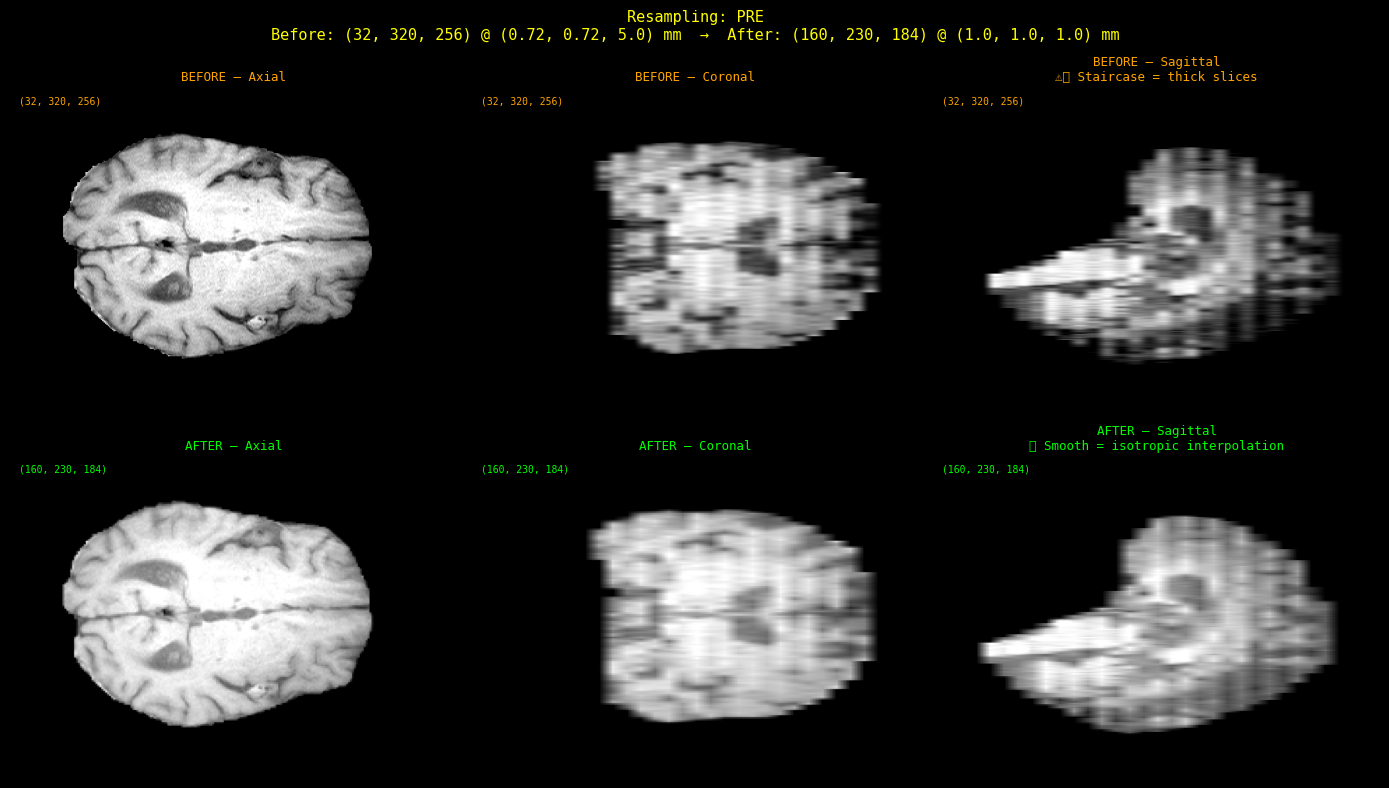

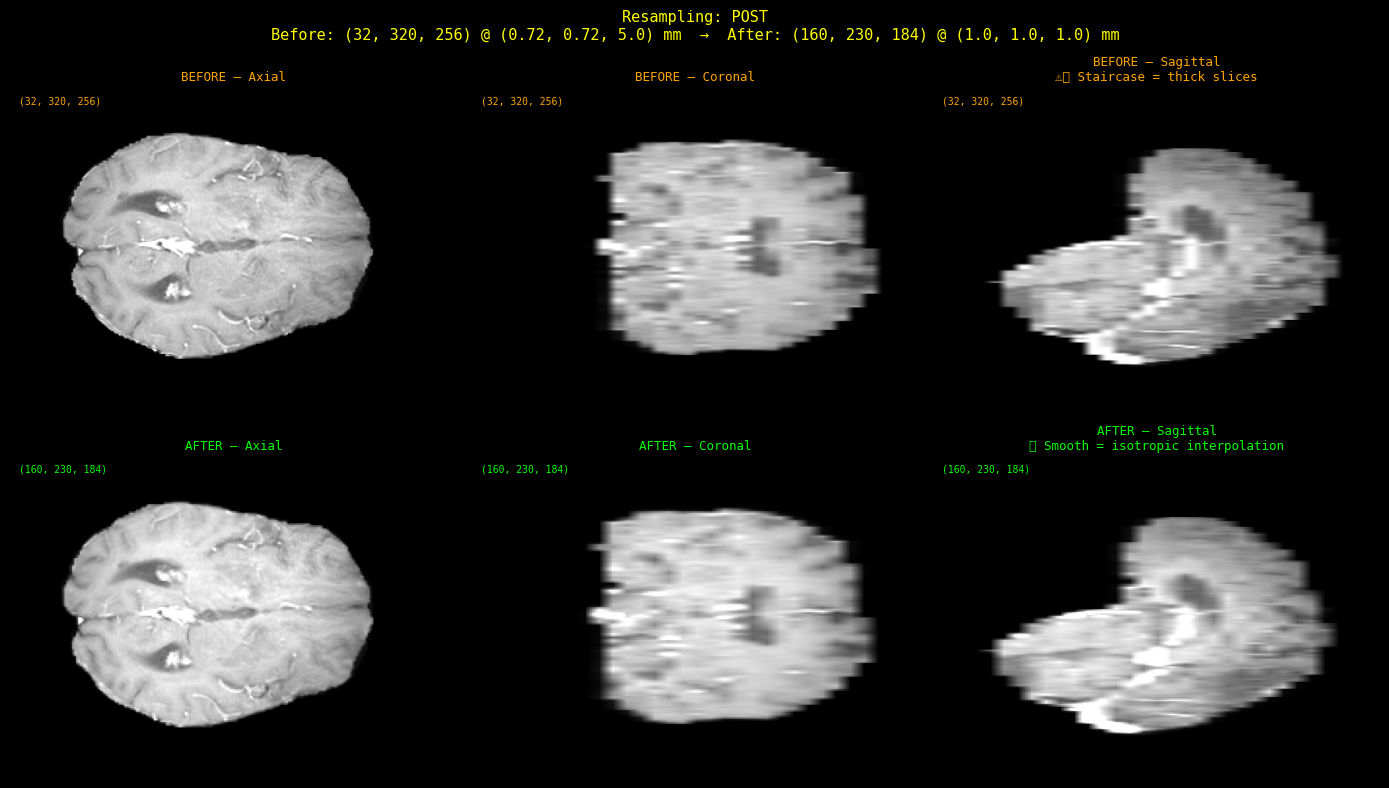

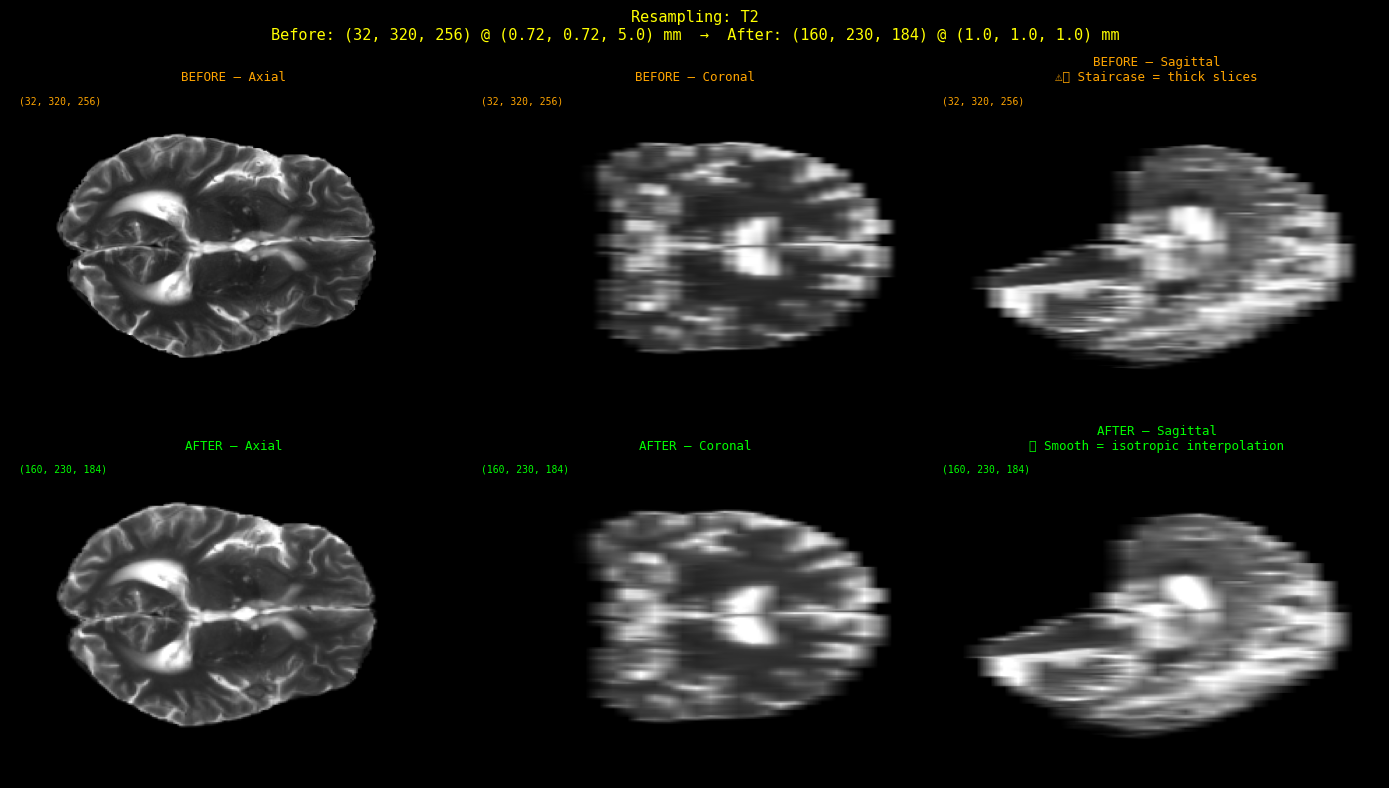

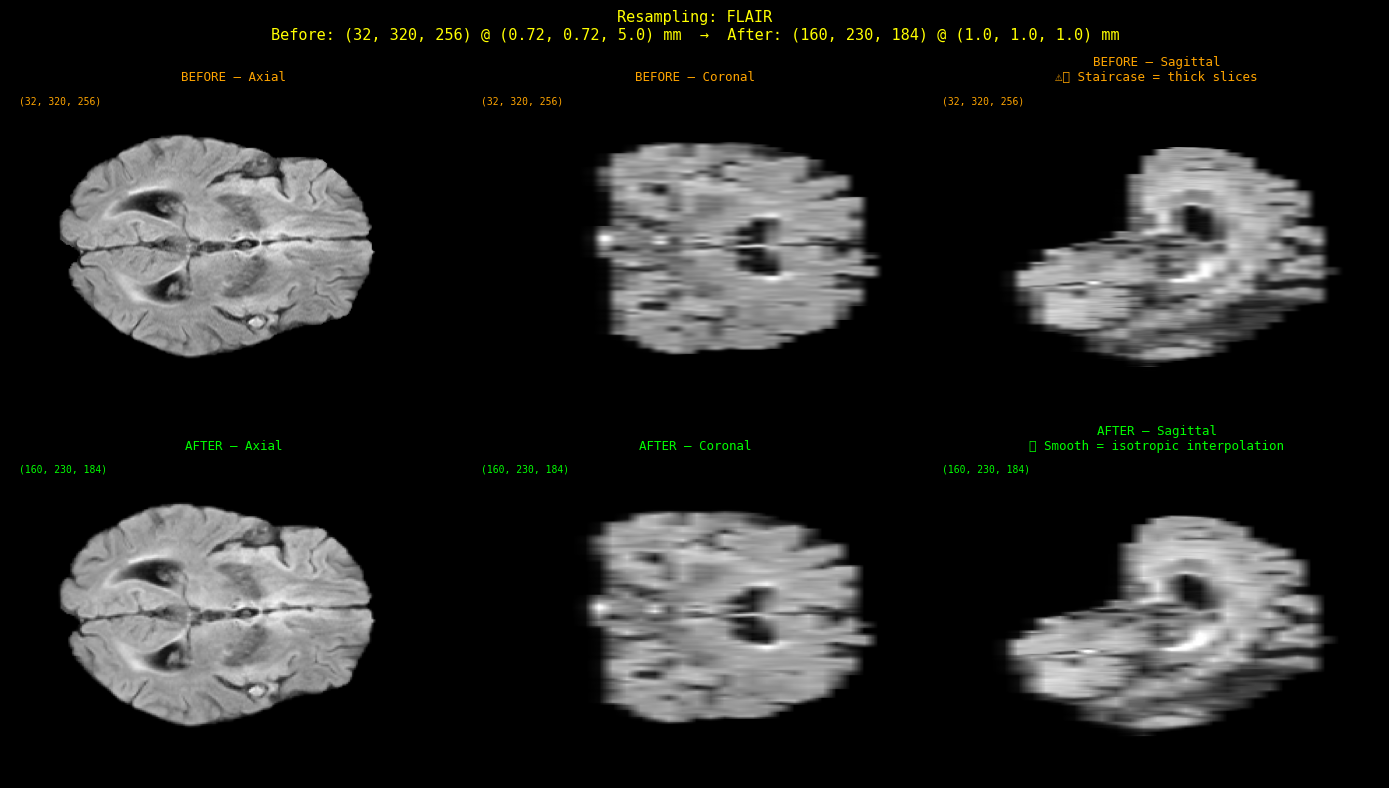

In [9]:
def plot_resampling_before_after(before_np, after_np, mod_name,
                                  before_spacing, after_spacing):
    """
    Side-by-side comparison of axial/coronal/sagittal views before and after resampling.
    Also shows the effect on through-plane resolution (sagittal view is most informative).
    """
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    fig.patch.set_facecolor("black")
    fig.suptitle(
        f"Resampling: {mod_name}\n"
        f"Before: {before_np.shape} @ {tuple(round(s,2) for s in before_spacing)} mm  →  "
        f"After: {after_np.shape} @ {tuple(round(s,2) for s in after_spacing)} mm",
        fontsize=11, color="yellow"
    )

    p1b, p99b = np.percentile(before_np[before_np > 0], [1, 99]) if before_np.max() > 0 else (0, 1)
    p1a, p99a = np.percentile(after_np[after_np > 0], [1, 99]) if after_np.max() > 0 else (0, 1)

    views = [
        ("Axial",    lambda d: np.rot90(d[d.shape[0]//2, :, :])),
        ("Coronal",  lambda d: np.rot90(d[:, d.shape[1]//2, :])),
        ("Sagittal", lambda d: np.rot90(d[:, :, d.shape[2]//2])),
    ]

    for col, (view_name, slicer) in enumerate(views):
        sl_before = slicer(before_np)
        sl_after  = slicer(after_np)

        axes[0, col].imshow(sl_before, cmap="gray", vmin=p1b, vmax=p99b, aspect="auto")
        axes[0, col].set_title(f"BEFORE — {view_name}", color="orange", fontsize=9)
        axes[0, col].axis("off")
        axes[0, col].text(0.02, 0.98, f"{before_np.shape}", transform=axes[0, col].transAxes,
                          color="orange", fontsize=7, va="top")

        axes[1, col].imshow(sl_after, cmap="gray", vmin=p1a, vmax=p99a, aspect="auto")
        axes[1, col].set_title(f"AFTER — {view_name}", color="lime", fontsize=9)
        axes[1, col].axis("off")
        axes[1, col].text(0.02, 0.98, f"{after_np.shape}", transform=axes[1, col].transAxes,
                          color="lime", fontsize=7, va="top")

    # Annotation on sagittal (most impacted by thick slices)
    axes[0, 2].set_title("BEFORE — Sagittal\n⚠️ Staircase = thick slices", color="orange", fontsize=9)
    axes[1, 2].set_title("AFTER — Sagittal\n✅ Smooth = isotropic interpolation", color="lime", fontsize=9)

    plt.tight_layout()
    plt.savefig(str(BASE_DIR / "outputs" / "eda" / "figures" /
                    f"preproc_02_resampling_{mod_name}.png"),
                dpi=100, bbox_inches="tight", facecolor="black")
    plt.show()


for mod in MODALITIES:
    plot_resampling_before_after(
        before_np      = registered_np[mod],
        after_np       = resampled_np[mod],
        mod_name       = mod,
        before_spacing = registered_sitk[mod].GetSpacing(),
        after_spacing  = resampled_sitk[mod].GetSpacing(),
    )

---
## Section 7 — Step 3: Intensity Normalization

### Why Is This Needed?

MRI **does not have an absolute intensity scale** (unlike CT where air = -1000 HU, bone = +1000 HU).

The same scanner at the same field strength can produce values of:
- `0–500` on one acquisition
- `0–50,000` on another

This is due to:
- Different receiver coil gain settings
- Different echo time / repetition time
- Scanner vendor differences (Siemens vs GE)
- Even patient-to-patient body differences

**Without normalization**: a CNN might learn "high intensity = tumor" when it's really just "high gain setting on this scanner". The model memorizes scanner artifacts, not biology.

### What We Do: Z-Score Per Volume

1. Compute the **1st and 99th percentile** of the brain voxels (exclude background zeros)
2. **Clip** values outside this range to remove extreme outliers (e.g. bright artifacts)
3. Compute **mean** and **std** of the clipped brain voxels
4. Apply `(x - mean) / std`

**Result**: every volume has mean≈0 and std≈1, regardless of scanner or acquisition settings.

### Why Clip at 1–99th Percentile First?

A single bright artifact voxel can inflate the std dramatically, making the whole brain appear near-zero after normalization. Clipping first removes this effect.

In [10]:
def normalize_zscore(vol: np.ndarray,
                     clip_pct: tuple = CLIP_PERCENTILE) -> np.ndarray:
    """
    Z-score normalization with percentile clipping.

    Steps
    -----
    1. Extract brain voxels (> 0 after skull stripping)
    2. Compute clip_pct[0] and clip_pct[1] percentiles of brain voxels
    3. Clip the entire volume to [p_low, p_high]
    4. Recompute mean and std on brain voxels after clipping
    5. Z-score: (vol - mean) / std

    Returns float32 numpy array with same shape as input.
    """
    vol    = vol.astype(np.float32)
    brain  = vol[vol > 0]

    if len(brain) == 0:
        return vol   # empty volume — return as-is

    p_low, p_high = np.percentile(brain, clip_pct)
    vol_clipped   = np.clip(vol, p_low, p_high)

    # Recompute brain mask on clipped volume
    brain_clipped = vol_clipped[vol_clipped > 0]
    mean = brain_clipped.mean()
    std  = brain_clipped.std()

    if std < 1e-8:
        std = 1.0   # degenerate case — flat image

    vol_norm = (vol_clipped - mean) / std
    # Re-zero the background (was slightly shifted by mean subtraction)
    vol_norm[vol == 0] = 0.0

    return vol_norm.astype(np.float32)


# ─────────────────────────────────────────────────────────────────────────────
# Apply normalization to all resampled volumes
# ─────────────────────────────────────────────────────────────────────────────
normalized_np = {}

print("Applying z-score normalization:")
print()
for mod in MODALITIES:
    pre  = resampled_np[mod]
    post = normalize_zscore(pre)
    normalized_np[mod] = post

    brain_pre  = pre[pre > 0]
    brain_post = post[post != 0]
    print(f"  {mod:5s}  BEFORE → min={pre.min():.1f}  max={pre.max():.1f}  "
          f"mean={brain_pre.mean():.1f}  std={brain_pre.std():.1f}")
    print(f"         AFTER  → min={post.min():.2f}  max={post.max():.2f}  "
          f"mean={brain_post.mean():.2f}  std={brain_post.std():.2f}")
    print()

print("✅  Normalization complete.")

Applying z-score normalization:

  PRE    BEFORE → min=0.0  max=537.7  mean=237.1  std=84.7
         AFTER  → min=-0.46  max=3.19  mean=1.89  std=0.84

  POST   BEFORE → min=0.0  max=1054.4  mean=246.2  std=108.0
         AFTER  → min=-0.46  max=3.13  mean=1.75  std=0.96

  PRE    BEFORE → min=0.0  max=537.7  mean=237.1  std=84.7
         AFTER  → min=-0.46  max=3.19  mean=1.89  std=0.84

  POST   BEFORE → min=0.0  max=1054.4  mean=246.2  std=108.0
         AFTER  → min=-0.46  max=3.13  mean=1.75  std=0.96

  T2     BEFORE → min=0.0  max=1892.2  mean=503.2  std=304.4
         AFTER  → min=-0.44  max=5.37  mean=1.58  std=1.20

  FLAIR  BEFORE → min=0.0  max=561.3  mean=219.7  std=108.0
         AFTER  → min=-0.44  max=3.95  mean=1.73  std=1.06

✅  Normalization complete.
  T2     BEFORE → min=0.0  max=1892.2  mean=503.2  std=304.4
         AFTER  → min=-0.44  max=5.37  mean=1.58  std=1.20

  FLAIR  BEFORE → min=0.0  max=561.3  mean=219.7  std=108.0
         AFTER  → min=-0.44  max=3.95 

---
## 📊 Before & After — Intensity Normalization

What to look for:
- **Histogram**: before = wide, asymmetric, high-valued. After = centered at 0, unit std
- **Visual slices**: same anatomical content, window/level auto-adjusts — brain tissue should look identical
- **Printed stats**: mean should be ≈0, std ≈1 after normalization

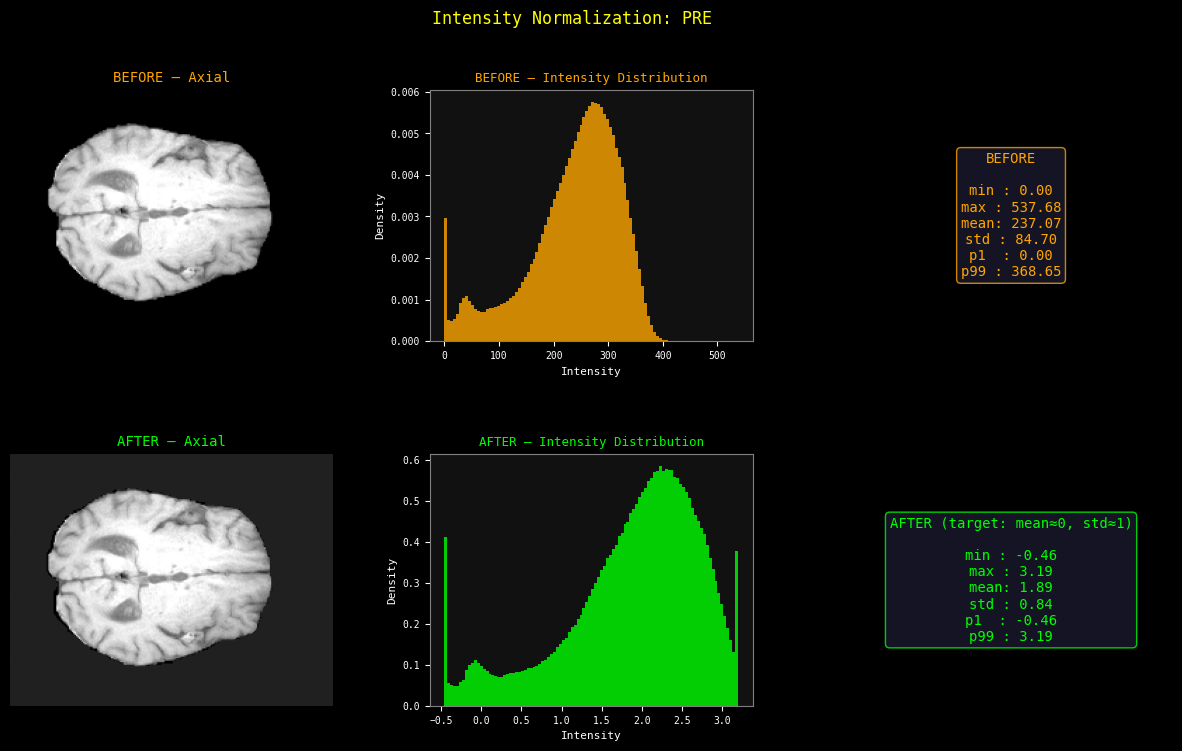

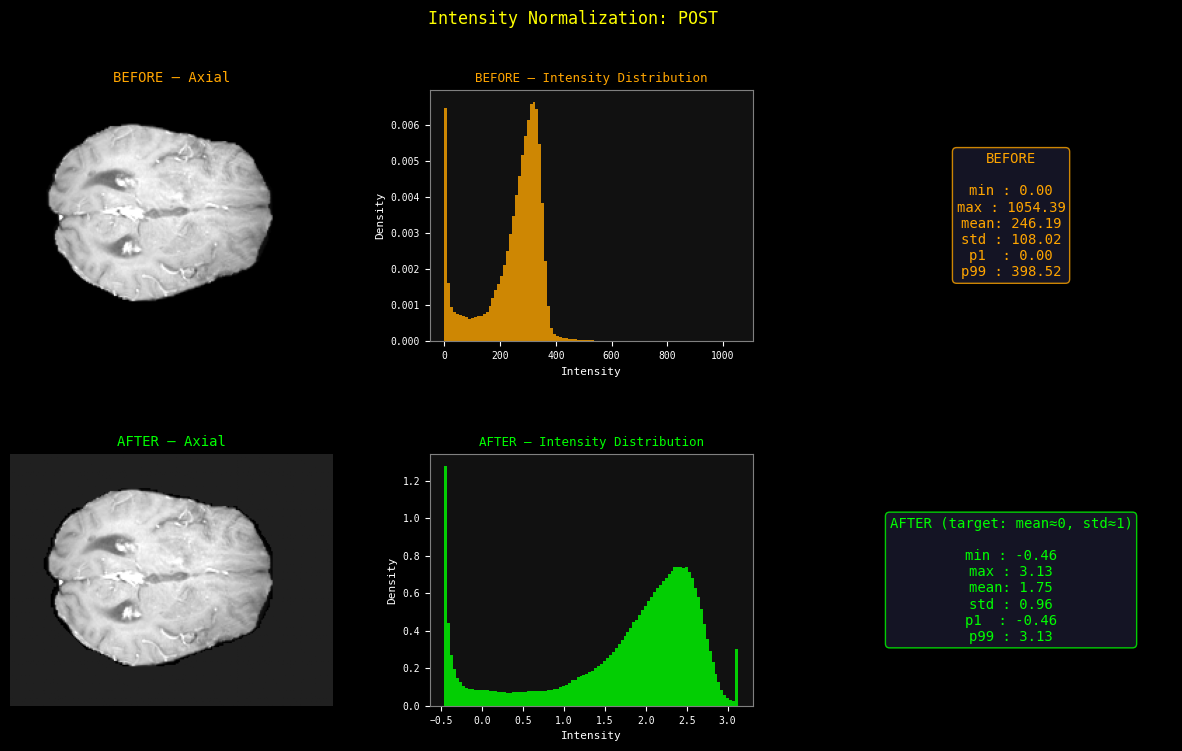

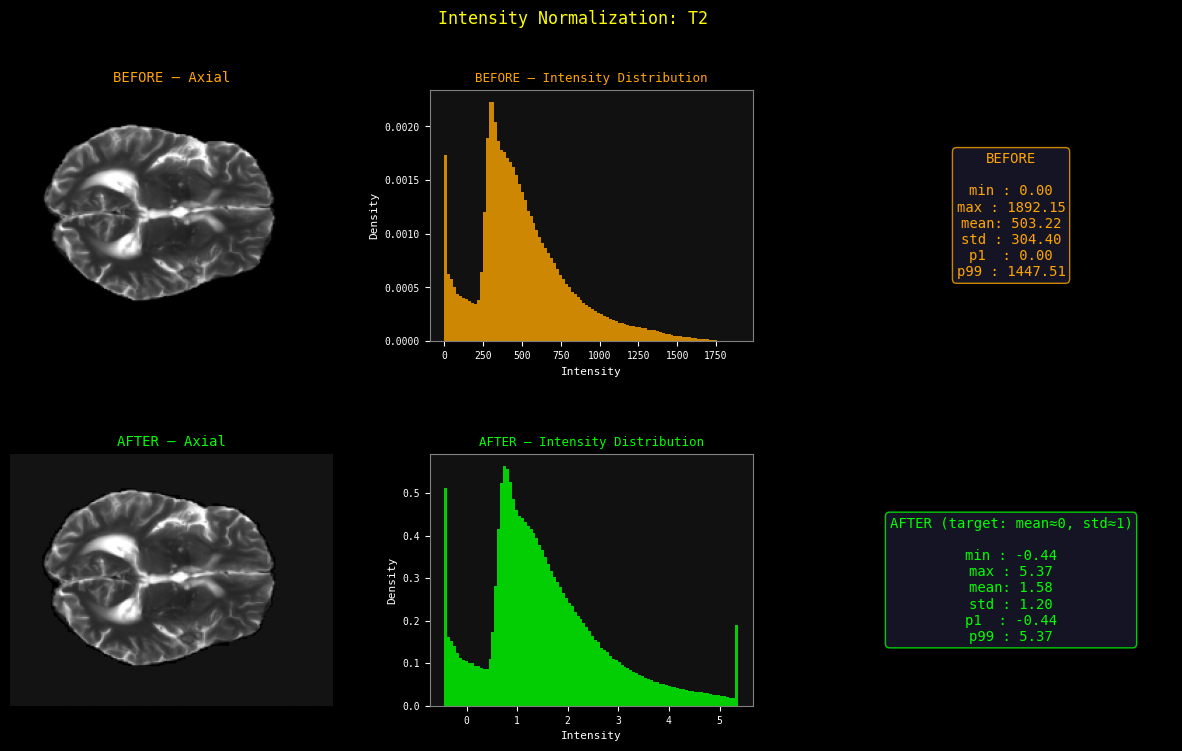

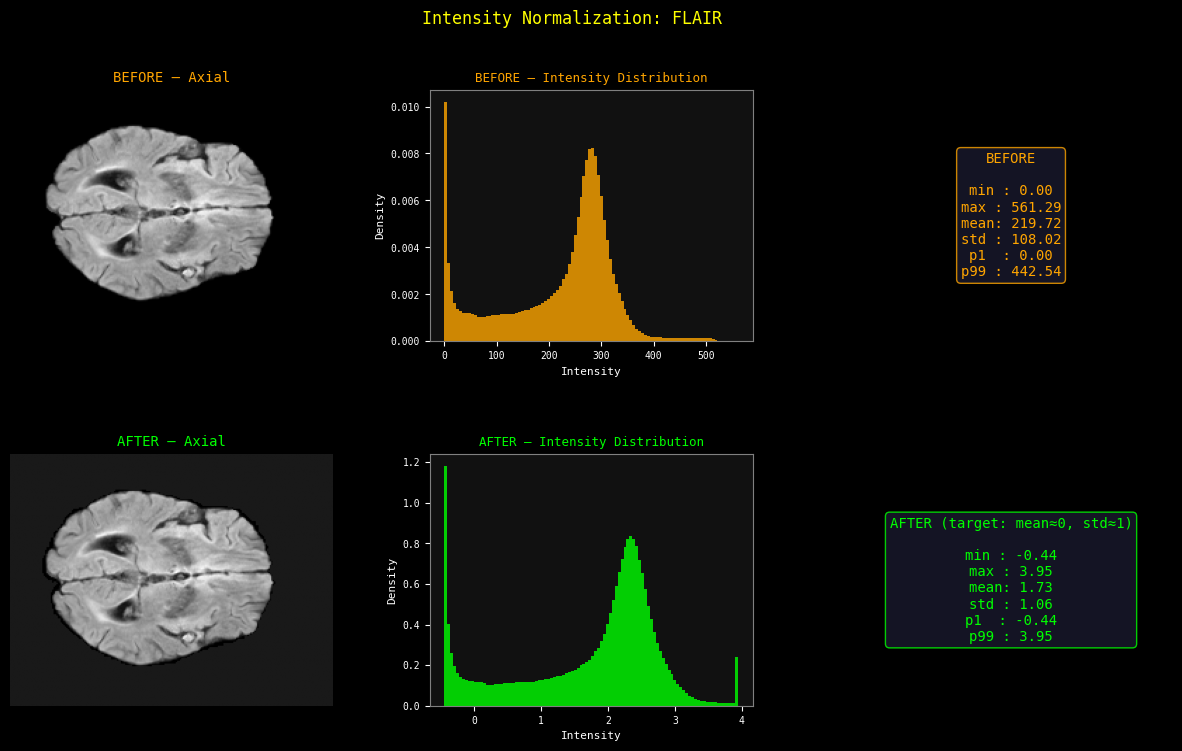

In [11]:
def plot_normalization_before_after(before_np, after_np, mod_name):
    """
    2×3 grid:
      Row 0: axial slice before | histogram before | stats before
      Row 1: axial slice after  | histogram after  | stats after
    """
    fig = plt.figure(figsize=(15, 8))
    fig.patch.set_facecolor("black")
    fig.suptitle(f"Intensity Normalization: {mod_name}", fontsize=12, color="yellow")
    gs = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.3)

    z = before_np.shape[0] // 2
    sl_before = np.rot90(before_np[z])
    sl_after  = np.rot90(after_np[z])

    brain_before = before_np[before_np > 0]
    brain_after  = after_np[after_np != 0]

    p1b, p99b = np.percentile(brain_before, [1, 99]) if len(brain_before) > 0 else (0, 1)
    p1a, p99a = np.percentile(brain_after,  [1, 99]) if len(brain_after)  > 0 else (-1, 1)

    # Axial slices
    for row, (sl, vmin, vmax, color, label) in enumerate([
        (sl_before, p1b, p99b, "orange", "BEFORE"),
        (sl_after,  p1a, p99a, "lime",   "AFTER"),
    ]):
        ax = fig.add_subplot(gs[row, 0])
        ax.imshow(sl, cmap="gray", vmin=vmin, vmax=vmax, aspect="auto")
        ax.set_title(f"{label} — Axial", color=color, fontsize=10)
        ax.axis("off")

    # Histograms
    for row, (brain, color, label) in enumerate([
        (brain_before, "orange", "BEFORE"),
        (brain_after,  "lime",   "AFTER"),
    ]):
        ax = fig.add_subplot(gs[row, 1])
        ax.set_facecolor("#111111")
        ax.hist(brain, bins=100, color=color, alpha=0.8, density=True)
        ax.set_title(f"{label} — Intensity Distribution", color=color, fontsize=9)
        ax.set_xlabel("Intensity", color="white", fontsize=8)
        ax.set_ylabel("Density", color="white", fontsize=8)
        ax.tick_params(colors="white", labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor("gray")

    # Stats boxes
    def stats_text(brain, label, color):
        return (f"{label}\n\n"
                f"min : {brain.min():.2f}\n"
                f"max : {brain.max():.2f}\n"
                f"mean: {brain.mean():.2f}\n"
                f"std : {brain.std():.2f}\n"
                f"p1  : {np.percentile(brain, 1):.2f}\n"
                f"p99 : {np.percentile(brain, 99):.2f}")

    for row, (brain, color, label) in enumerate([
        (brain_before, "orange", "BEFORE"),
        (brain_after,  "lime",   "AFTER (target: mean≈0, std≈1)"),
    ]):
        ax = fig.add_subplot(gs[row, 2])
        ax.set_facecolor("black")
        ax.axis("off")
        ax.text(0.5, 0.5, stats_text(brain, label, color),
                ha="center", va="center", color=color, fontsize=10,
                transform=ax.transAxes, fontfamily="monospace",
                bbox=dict(boxstyle="round", facecolor="#1a1a2e", edgecolor=color, alpha=0.8))

    plt.savefig(str(BASE_DIR / "outputs" / "eda" / "figures" /
                    f"preproc_03_normalization_{mod_name}.png"),
                dpi=100, bbox_inches="tight", facecolor="black")
    plt.show()


for mod in MODALITIES:
    plot_normalization_before_after(
        before_np = resampled_np[mod],
        after_np  = normalized_np[mod],
        mod_name  = mod,
    )

---
## Section 8 — Full 4-Channel Side-by-Side Overview

After all 3 steps, overlay all 4 modalities at the same anatomical position to confirm they are now truly co-registered and normalized. Each modality should show the **same brain structure** at the same slice index.

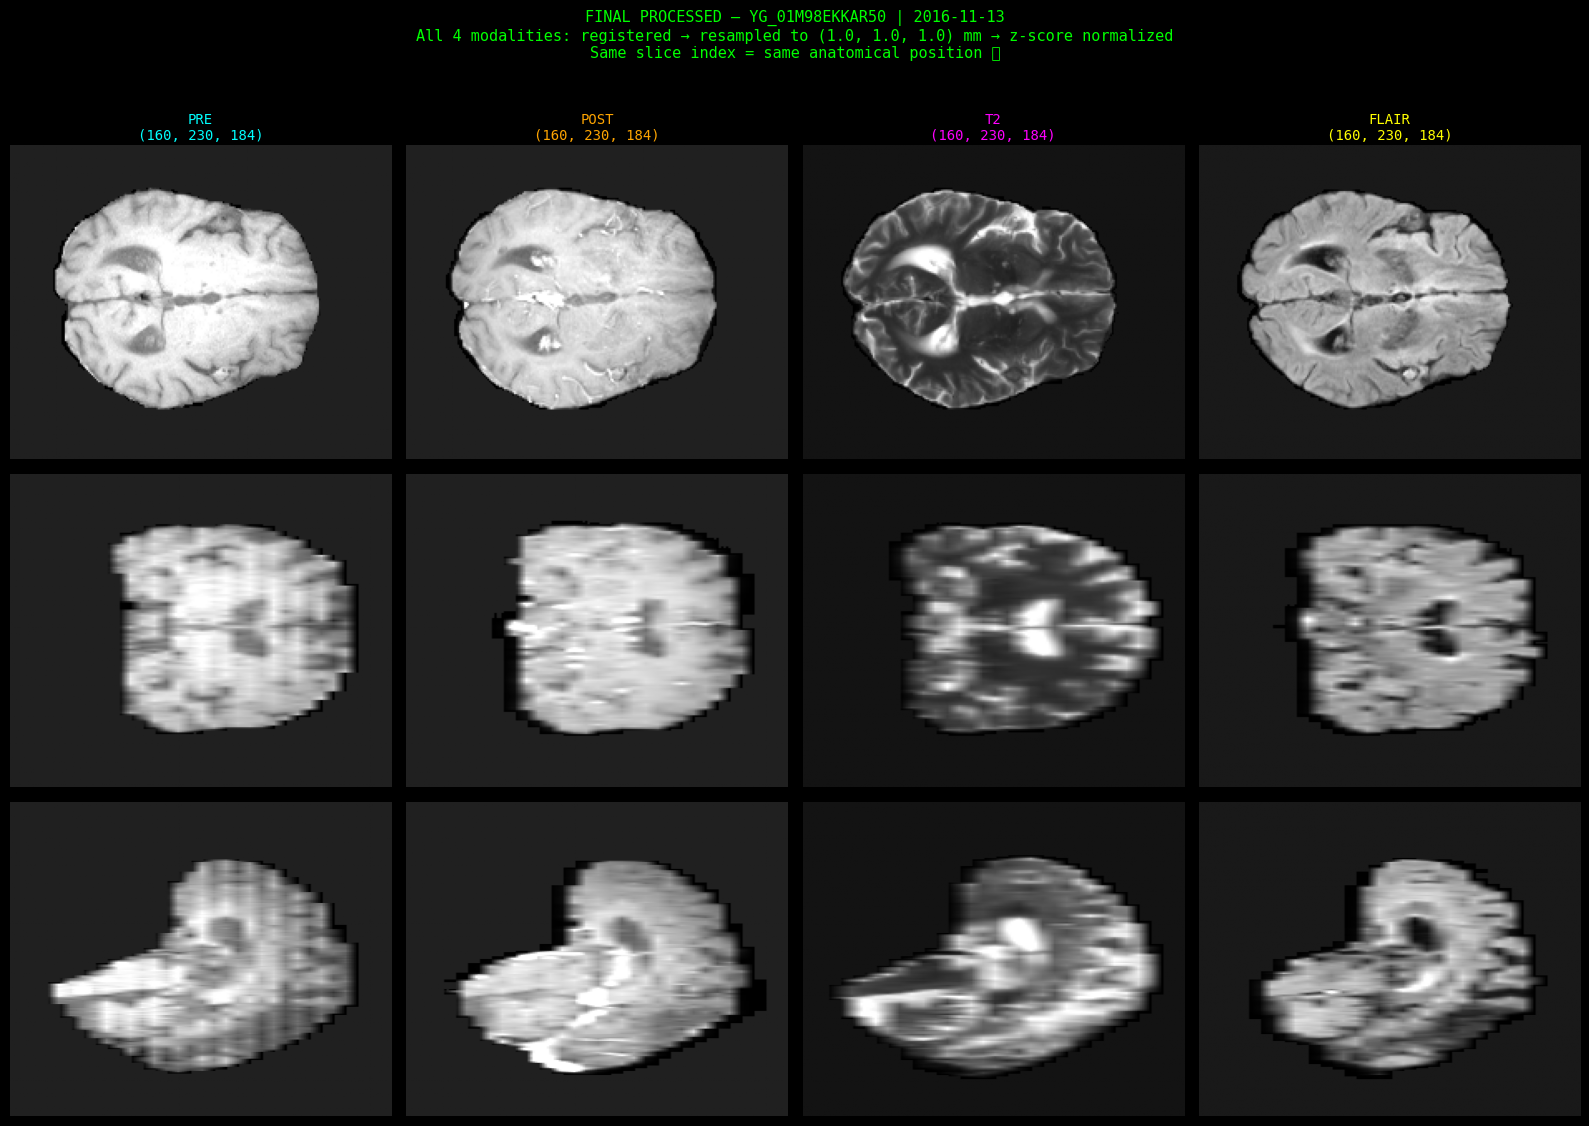

✅  4-channel final overview saved.


In [12]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.patch.set_facecolor("black")
fig.suptitle(
    f"FINAL PROCESSED — {TEST_PATIENT} | {TEST_VISIT}\n"
    f"All 4 modalities: registered → resampled to {TARGET_SPACING} mm → z-score normalized\n"
    f"Same slice index = same anatomical position ✅",
    fontsize=11, color="lime", y=1.02
)

view_labels = ["Axial (z//2)", "Coronal (y//2)", "Sagittal (x//2)"]
mod_colors  = {"PRE": "cyan", "POST": "orange", "T2": "magenta", "FLAIR": "yellow"}

for col, mod in enumerate(MODALITIES):
    vol = normalized_np[mod]
    z, y, x = vol.shape
    slices = [
        np.rot90(vol[z//2, :, :]),
        np.rot90(vol[:, y//2, :]),
        np.rot90(vol[:, :, x//2]),
    ]
    p1, p99 = np.percentile(vol[vol != 0], [1, 99]) if vol.max() != vol.min() else (-1, 1)
    color = mod_colors[mod]
    for row, sl in enumerate(slices):
        ax = axes[row, col]
        ax.imshow(sl, cmap="gray", vmin=p1, vmax=p99, aspect="auto")
        ax.axis("off")
        if row == 0:
            ax.set_title(f"{mod}\n{vol.shape}", color=color, fontsize=10, pad=4)
        if col == 0:
            ax.set_ylabel(view_labels[row], color="white", fontsize=8, rotation=90, labelpad=4)

plt.tight_layout()
plt.savefig(str(BASE_DIR / "outputs" / "eda" / "figures" /
                "preproc_04_final_4channel.png"),
            dpi=100, bbox_inches="tight", facecolor="black")
plt.show()
print("✅  4-channel final overview saved.")

---
## Section 9 — Save & Idempotency Check

Save the processed volumes as compressed NIfTI (`.nii.gz`) to `Data/processed/`.

**Naming convention**: `{OUTPUT_DIR}/{patient_id}/{visit_date}/{MOD}.nii.gz`  
e.g. `Data/processed/YG_01M98EKKAR50/2016-11-13/POST.nii.gz`

**Idempotency**: If the output file already exists, skip and log `"skipped"`. Safe to re-run the full dataset pipeline after any interruption without re-doing work.

In [13]:
def processed_filename(raw_path: Path, mod: str) -> str:
    """
    Derive the processed output filename from the raw Yale path.

    Raw    : YG_01M98EKKAR50_2016-11-13_10-16-23_PRE.nii.gz
    Output : YG_01M98EKKAR50_2016-11-13_10-16-23_PRE_processed.nii.gz

    This preserves the full Yale naming convention (patient + date + time + mod)
    and makes it obvious which raw file each processed file came from.
    """
    stem = raw_path.name.replace(".nii.gz", "")   # strip .nii.gz
    return f"{stem}_processed.nii.gz"


def save_processed_visit(patient_id: str, visit_date: str,
                          normalized_np: dict,
                          raw_paths: dict,
                          reference_sitk: sitk.Image,
                          output_root: Path = OUTPUT_DIR) -> dict:
    """
    Save all processed modalities for one visit, keeping the original Yale filename.

    Parameters
    ----------
    patient_id    : e.g. 'YG_01M98EKKAR50'
    visit_date    : e.g. '2016-11-13'
    normalized_np : dict {mod: np.ndarray} — final processed arrays
    raw_paths     : dict {mod: Path} — original raw paths (to derive output name)
    reference_sitk: the fixed image after resampling (copies geometry to output)
    output_root   : base output directory

    Returns
    -------
    dict : {mod: ('saved'|'skipped'|'error: ...')}

    Output structure on HDD:
      /media/moamed/Data/yale-processed/
          YG_01M98EKKAR50/
              2016-11-13/
                  YG_01M98EKKAR50_2016-11-13_10-16-23_PRE_processed.nii.gz
                  YG_01M98EKKAR50_2016-11-13_10-16-23_POST_processed.nii.gz
                  YG_01M98EKKAR50_2016-11-13_10-16-23_T2_processed.nii.gz
                  YG_01M98EKKAR50_2016-11-13_10-16-23_FLAIR_processed.nii.gz
    """
    visit_dir = output_root / patient_id / visit_date
    visit_dir.mkdir(parents=True, exist_ok=True)

    statuses = {}
    for mod, vol_np in normalized_np.items():
        raw_p    = Path(str(raw_paths[mod]))
        out_name = processed_filename(raw_p, mod)
        out_path = visit_dir / out_name

        if out_path.exists():
            statuses[mod] = "skipped"
            continue

        try:
            out_img = sitk.GetImageFromArray(vol_np)
            out_img.CopyInformation(reference_sitk)
            sitk.WriteImage(out_img, str(out_path), useCompression=True)
            statuses[mod] = "saved"
        except Exception as e:
            statuses[mod] = f"error: {e}"

    return statuses


# ─────────────────────────────────────────────────────────────────────────────
# Save the test patient
# ─────────────────────────────────────────────────────────────────────────────
t0 = time.time()
statuses = save_processed_visit(
    patient_id    = TEST_PATIENT,
    visit_date    = TEST_VISIT,
    normalized_np = normalized_np,
    raw_paths     = RAW_PATHS,
    reference_sitk= resampled_sitk[FIXED_MOD],
)
elapsed = time.time() - t0

out_dir = OUTPUT_DIR / TEST_PATIENT / TEST_VISIT
print(f"Saved to: {out_dir}/")
print()
for mod, status in statuses.items():
    icon = "✅" if status == "saved" else ("⏭️" if status == "skipped" else "❌")
    raw_p    = Path(str(RAW_PATHS[mod]))
    out_path = out_dir / processed_filename(raw_p, mod)
    size_mb  = out_path.stat().st_size / 1e6 if out_path.exists() else 0
    print(f"  {icon}  {mod:5s}: {status:10s}  ({size_mb:.1f} MB)  → {out_path.name}")

print(f"\nWrite time: {elapsed:.2f}s")


Saved to: /media/moamed/Data/yale-processed/YG_01M98EKKAR50/2016-11-13/

  ⏭️  PRE  : skipped     (4.7 MB)  → YG_01M98EKKAR50_2016-11-13_10-16-23_PRE_processed.nii.gz
  ⏭️  POST : skipped     (5.0 MB)  → YG_01M98EKKAR50_2016-11-13_10-16-23_POST_processed.nii.gz
  ⏭️  T2   : skipped     (5.3 MB)  → YG_01M98EKKAR50_2016-11-13_10-16-23_T2_processed.nii.gz
  ⏭️  FLAIR: skipped     (4.9 MB)  → YG_01M98EKKAR50_2016-11-13_10-16-23_FLAIR_processed.nii.gz

Write time: 0.15s


---
## Section 10 — Validation: Reload & Verify Saved Output

Always reload the saved file and verify it's correct. This catches:
- Spacing corruption (wrong metadata written)
- dtype issues (accidentally saved as int16 instead of float32)
- NaN/Inf values (from normalization edge cases)
- Shape mismatch (resampler rounding error)

In [14]:
print("=" * 65)
print(f"  VALIDATION REPORT — {TEST_PATIENT} / {TEST_VISIT}")
print("=" * 65)

all_pass = True
visit_dir = OUTPUT_DIR / TEST_PATIENT / TEST_VISIT

for mod in MODALITIES:
    if mod not in RAW_PATHS:
        print(f"  ⏭️  {mod}: NOT IN THIS VISIT (skipped)")
        continue

    # Derive the processed filename from the original Yale raw path
    raw_p    = Path(str(RAW_PATHS[mod]))
    out_name = processed_filename(raw_p, mod)
    out_path = visit_dir / out_name

    if not out_path.exists():
        print(f"  ❌  {mod}: FILE NOT FOUND")
        print(f"       Expected: {out_path}")
        all_pass = False
        continue

    img  = sitk.ReadImage(str(out_path))
    arr  = sitk.GetArrayFromImage(img)
    sp   = img.GetSpacing()

    checks = {
        "spacing_1mm"  : all(abs(s - 1.0) < 0.01 for s in sp),
        "dtype_float32": arr.dtype == np.float32,
        "no_nan"       : not np.isnan(arr).any(),
        "no_inf"       : not np.isinf(arr).any(),
        "shape_3d"     : arr.ndim == 3,
        "min_z_slices" : arr.shape[0] >= 50,  # at least 50 slices after 1mm resample
    }

    brain  = arr[arr != 0]
    status = "✅" if all(checks.values()) else "⚠️"
    if not all(checks.values()):
        all_pass = False

    print(f"\n  {status}  {mod}  →  {out_name}")
    print(f"       Shape    : {arr.shape}")
    print(f"       Spacing  : {tuple(round(s, 4) for s in sp)} mm")
    print(f"       Dtype    : {arr.dtype}")
    print(f"       Brain px : {len(brain):,}  ({100*len(brain)/arr.size:.1f}%)")
    if len(brain) > 0:
        print(f"       Mean/Std : {brain.mean():.3f} / {brain.std():.3f}  "
              f"(target ≈ 0 / 1)")
        print(f"       [min,max]: [{arr.min():.2f}, {arr.max():.2f}]")
    failed = [k for k, v in checks.items() if not v]
    if failed:
        print(f"       ❌ FAILED: {failed}")
    else:
        print(f"       All checks passed ✅")

print()
print("=" * 65)
if all_pass:
    print("  🎉  ALL MODALITIES VALIDATED SUCCESSFULLY")
else:
    print("  ⚠️  SOME CHECKS FAILED — see above")
print("=" * 65)


  VALIDATION REPORT — YG_01M98EKKAR50 / 2016-11-13

  ✅  PRE  →  YG_01M98EKKAR50_2016-11-13_10-16-23_PRE_processed.nii.gz
       Shape    : (160, 230, 184)
       Spacing  : (1.0, 1.0, 1.0) mm
       Dtype    : float32
       Brain px : 1,317,668  (19.5%)
       Mean/Std : 1.891 / 0.837  (target ≈ 0 / 1)
       [min,max]: [-0.46, 3.19]
       All checks passed ✅

  ✅  POST  →  YG_01M98EKKAR50_2016-11-13_10-16-23_POST_processed.nii.gz
       Shape    : (160, 230, 184)
       Spacing  : (1.0, 1.0, 1.0) mm
       Dtype    : float32
       Brain px : 1,414,858  (20.9%)
       Mean/Std : 1.749 / 0.959  (target ≈ 0 / 1)
       [min,max]: [-0.46, 3.13]
       All checks passed ✅

  ✅  T2  →  YG_01M98EKKAR50_2016-11-13_10-16-23_T2_processed.nii.gz
       Shape    : (160, 230, 184)
       Spacing  : (1.0, 1.0, 1.0) mm
       Dtype    : float32
       Brain px : 1,465,340  (21.6%)
       Mean/Std : 1.577 / 1.204  (target ≈ 0 / 1)
       [min,max]: [-0.44, 5.37]
       All checks passed ✅

  ✅  P

---
## Section 11 — Full Pipeline Function (Idempotent, CSV-Logged)

This wraps everything into a single `run_pipeline_visit()` function ready to be called in a batch loop over all 11,877 visits.

**Log format** (`preprocessing_log.csv`):
```
patient_id | visit_date | status | n_modalities | time_s | error_msg | timestamp
```
- `status`: `success` / `skipped` / `partial` / `failed`
- Append-only — never overwrites previous log entries

In [15]:
import csv
from datetime import datetime as dt

def log_result(log_path: Path, patient_id, visit_date, status,
               n_mod=0, time_s=0.0, error_msg=""):
    """Append one row to preprocessing_log.csv."""
    write_header = not log_path.exists()
    with open(log_path, "a", newline="") as f:
        w = csv.writer(f)
        if write_header:
            w.writerow(["patient_id", "visit_date", "status",
                        "n_modalities_saved", "time_s", "error_msg", "timestamp"])
        w.writerow([patient_id, visit_date, status, n_mod,
                    round(time_s, 2), error_msg,
                    dt.now().strftime("%Y-%m-%d %H:%M:%S")])


def run_pipeline_visit(patient_id: str, visit_date: str,
                       paths: dict,
                       output_root: Path = OUTPUT_DIR,
                       log_path: Path = LOG_PATH) -> str:
    """
    Full preprocessing pipeline for ONE visit.

    Parameters
    ----------
    patient_id  : e.g. 'YG_01M98EKKAR50'
    visit_date  : e.g. '2016-11-13'
    paths       : dict {mod: Path|str|None} — raw NIfTI paths
    output_root : base output directory (HDD)
    log_path    : path to preprocessing_log.csv

    Returns
    -------
    str : 'success', 'skipped', 'partial', or 'failed'

    Output filenames follow original Yale convention:
      YG_<ID>_<DATE>_<TIME>_<MOD>_processed.nii.gz
    """
    visit_dir = output_root / patient_id / visit_date

    # ── Resolve available modalities ───────────────────────────────────────
    available_mods = [m for m, p in paths.items()
                      if p is not None and pd.notna(str(p)) and Path(str(p)).exists()]
    # Cast paths to Path objects for available mods
    path_objs = {m: Path(str(paths[m])) for m in available_mods}

    # ── Idempotency check — uses Yale-derived output filenames ─────────────
    expected_outputs = [
        visit_dir / processed_filename(path_objs[m], m)
        for m in available_mods
    ]
    if all(p.exists() for p in expected_outputs) and len(expected_outputs) > 0:
        log_result(log_path, patient_id, visit_date, "skipped",
                   n_mod=len(expected_outputs))
        return "skipped"

    t_start = time.time()
    try:
        # ── Load ────────────────────────────────────────────────────────────
        raw_imgs = {mod: sitk.ReadImage(str(path_objs[mod]), sitk.sitkFloat32)
                    for mod in available_mods}

        if FIXED_MOD not in raw_imgs:
            fixed_key = "POST" if "POST" in raw_imgs else available_mods[0]
        else:
            fixed_key = FIXED_MOD

        fixed_img = raw_imgs[fixed_key]

        # ── Step 1: Register all → fixed ────────────────────────────────────
        reg_imgs = {fixed_key: fixed_img}
        for mod in [m for m in available_mods if m != fixed_key]:
            reg_imgs[mod] = register_to_fixed(fixed_img, raw_imgs[mod])

        # ── Step 2: Resample to 1mm³ ─────────────────────────────────────────
        res_imgs = {}
        ref_img  = None
        for mod in available_mods:
            res_imgs[mod] = resample_to_isotropic(reg_imgs[mod])
            if mod == fixed_key:
                ref_img = res_imgs[mod]

        # ── Step 3: Normalize ────────────────────────────────────────────────
        norm_vols = {mod: normalize_zscore(sitk_to_numpy(res_imgs[mod]))
                     for mod in available_mods}

        # ── Save — pass raw_paths so filenames match original Yale naming ─────
        statuses = save_processed_visit(
            patient_id    = patient_id,
            visit_date    = visit_date,
            normalized_np = norm_vols,
            raw_paths     = path_objs,
            reference_sitk= ref_img,
            output_root   = output_root,
        )
        n_saved = sum(1 for s in statuses.values() if s in ("saved", "skipped"))
        elapsed = time.time() - t_start
        final_status = "success" if n_saved == len(available_mods) else "partial"
        log_result(log_path, patient_id, visit_date, final_status,
                   n_mod=n_saved, time_s=elapsed)
        return final_status

    except Exception as e:
        elapsed = time.time() - t_start
        log_result(log_path, patient_id, visit_date, "failed",
                   time_s=elapsed, error_msg=str(e)[:200])
        return f"failed: {e}"


# ─────────────────────────────────────────────────────────────────────────────
# Quick test — re-run on the same patient (should be "skipped" — idempotent)
# ─────────────────────────────────────────────────────────────────────────────
print("Testing idempotency (re-run on already-processed patient)...")
result = run_pipeline_visit(
    patient_id = TEST_PATIENT,
    visit_date = TEST_VISIT,
    paths      = RAW_PATHS,
)
print(f"Result: {result}  ← should say 'skipped' if test patient was already saved")


Testing idempotency (re-run on already-processed patient)...
Result: skipped  ← should say 'skipped' if test patient was already saved


---
## Section 12 — Batch Run: All Patients (All Splits)

Runs the full pipeline across **all** patients (train + val + test) and saves to the **1TB HDD** at `/media/moamed/Data/yale-processed/`.

> **Scope**: `FULL` visits only — all 4 modalities (PRE+POST+T2+FLAIR) present → **4,364 visits**  
> **Output naming**: keeps the original Yale convention — `YG_<ID>_<DATE>_<TIME>_<MOD>_processed.nii.gz`  
> **HDD free space**: 575 GB — FULL visits need ~85 GB (4,364 × 4 mods × 4.9 MB)

> ⏱️ **Runtime estimate**:  
> ~28s per visit × 4,364 visits ≈ **~34 hours** on 7 CPU cores (original quality params)  
> Launch before bed → done by next morning.

> ✅ **Idempotent**: already-processed visits are skipped automatically — safe to re-run after interruption.


In [16]:
from tqdm.auto import tqdm
import shutil

# ─────────────────────────────────────────────────────────────────────────────
# Check disk space on the HDD (output drive)
# ─────────────────────────────────────────────────────────────────────────────
hdd_path = Path("/media/moamed/Data")
total, used, free = shutil.disk_usage(str(hdd_path))
print(f"HDD space check ({hdd_path}):")
print(f"  Free : {free / 1e9:.1f} GB")
print(f"  Used : {used / 1e9:.1f} GB")
print(f"  Total: {total / 1e9:.1f} GB")
print()

if free / 1e9 < 100:
    print("⚠️  WARNING: Less than 100 GB free on HDD.")
else:
    print("✅  HDD has sufficient space.")
print()

# ─────────────────────────────────────────────────────────────────────────────
# Load splits
# ─────────────────────────────────────────────────────────────────────────────
with open(SPLITS) as f:
    splits = json.load(f)

PROCESS_SPLIT = "all"   # 'train' | 'val' | 'test' | 'all'

if PROCESS_SPLIT == "all":
    patient_ids = splits["train"] + splits["val"] + splits["test"]
else:
    patient_ids = splits[PROCESS_SPLIT]

# Filter to FULL visits only (all 4 modalities: PRE+POST+T2+FLAIR)
# These are the only visits usable for supervised CNN training in Phase 2
# PARTIAL_GOOD / POST_ONLY / UNUSABLE → skipped for now (revisit in Phase 4)
df_batch = df_inv[df_inv["patient_id"].isin(patient_ids)].copy()
df_batch = df_batch[df_batch["training_usability"] == "FULL"]
df_batch = df_batch.sort_values(["patient_id", "visit_date"]).reset_index(drop=True)

print(f"Processing split   : {PROCESS_SPLIT}")
print(f"Patients           : {df_batch['patient_id'].nunique()}")
print(f"Visits to process  : {len(df_batch)}")
print()

# ─────────────────────────────────────────────────────────────────────────────
# TIME CAP — stop cleanly after this many hours (idempotent: safe to rerun)
# ─────────────────────────────────────────────────────────────────────────────
TIME_CAP_HOURS = None     # ← change to None to run until complete
TIME_CAP_S     = TIME_CAP_HOURS * 3600 if TIME_CAP_HOURS else float("inf")

# ─────────────────────────────────────────────────────────────────────────────
# DRY RUN first — set DRY_RUN = False to launch
# ─────────────────────────────────────────────────────────────────────────────
DRY_RUN = False   # ← set to False to launch

if DRY_RUN:
    print("🔍  DRY RUN — showing first 5 visits that would be processed:")
    count = 0
    for _, row in df_batch.iterrows():
        paths = {m: (row[f"path_{m}"] if pd.notna(str(row[f"path_{m}"])) else None)
                 for m in MODALITIES}
        available = [m for m, p in paths.items()
                     if p is not None and pd.notna(str(p)) and Path(str(p)).exists()]
        visit_dir = OUTPUT_DIR / row["patient_id"] / row["visit_date"]
        already_done = all(
            (visit_dir / processed_filename(Path(str(row[f"path_{m}"])), m)).exists()
            for m in available if pd.notna(str(row[f"path_{m}"]))
        ) and len(available) > 0
        status = "SKIP (done)" if already_done else "PROCESS"
        if len(available) > 0:
            ex = processed_filename(Path(str(row[f"path_{available[0]}"])), available[0])
            print(f"  {row['patient_id']} | {row['visit_date']} | mods={available} | {status}")
            print(f"    → e.g. {ex}")
        count += 1
        if count >= 5:
            break
    print(f"\n  ... and {len(df_batch)-5} more visits.")
    print("\n⚠️  Set DRY_RUN = False to launch the actual batch.")

else:
    # ── ACTUAL BATCH RUN ───────────────────────────────────────────────────
    results  = {"success": 0, "skipped": 0, "partial": 0, "failed": 0}
    batch_t0 = time.time()

    cap_label = f"{TIME_CAP_HOURS}h cap" if TIME_CAP_HOURS else "no cap"
    print(f"⏱️  Time cap: {cap_label}  — already-processed visits will be skipped on next run.\n")

    with tqdm(total=len(df_batch), desc="Preprocessing", unit="visit") as pbar:
        for _, row in df_batch.iterrows():

            # ── Check time cap before starting each visit ──────────────────
            elapsed_total = time.time() - batch_t0
            if elapsed_total >= TIME_CAP_S:
                done_so_far = sum(results.values())
                print(f"\n⏰  TIME CAP REACHED ({TIME_CAP_HOURS}h) — stopped after "
                      f"{done_so_far} visits.")
                print(f"    Re-run this cell to continue (already-done visits are skipped).")
                break

            paths = {m: (Path(str(row[f"path_{m}"])) if pd.notna(str(row[f"path_{m}"])) else None)
                     for m in MODALITIES}
            status = run_pipeline_visit(
                patient_id = row["patient_id"],
                visit_date = row["visit_date"],
                paths      = paths,
            )
            key = status.split(":")[0]
            results[key] = results.get(key, 0) + 1

            wall = time.time() - batch_t0
            remaining_s = max(0, TIME_CAP_S - wall)
            pbar.set_postfix({**results,
                              "cap_left": f"{remaining_s/60:.0f}m"}, refresh=False)
            pbar.update(1)

    wall_h = (time.time() - batch_t0) / 3600
    print(f"\n{'=' * 50}")
    print(f"  BATCH STOPPED  (wall time: {wall_h:.2f}h)")
    for k, v in results.items():
        print(f"  {k:10s}: {v}")
    print(f"{'=' * 50}")
    print(f"\n  ✅  Re-run this cell any time to process remaining visits.")
    print(f"      Set TIME_CAP_HOURS = None to run until fully complete.")


HDD space check (/media/moamed/Data):
  Free : 515.6 GB
  Used : 277.7 GB
  Total: 793.3 GB

✅  HDD has sufficient space.

Processing split   : all
Patients           : 977
Visits to process  : 4364

⏱️  Time cap: no cap  — already-processed visits will be skipped on next run.



Preprocessing:   0%|          | 0/4364 [00:00<?, ?visit/s]


  BATCH STOPPED  (wall time: 6.55h)
  success   : 1916
  skipped   : 2440
  partial   : 0
  failed    : 8

  ✅  Re-run this cell any time to process remaining visits.
      Set TIME_CAP_HOURS = None to run until fully complete.


---
## Section 13 — Log Analysis & Batch Progress Report

After running the batch (or to check progress mid-run), reload the log CSV and report what's been done.

  PREPROCESSING LOG SUMMARY
  Total entries : 9648

  Status breakdown:
    skipped   :  5017  (52.0%)
    success   :  4599  (47.7%)
    failed    :    32  (0.3%)

  Avg time/visit : 11.9s
  Remaining      : ~-5,284 visits
  ETA            : ~-17.5 hours

  ⚠️  Failed visits (32):
    YG_0LCE6TOVHK67 | 2021-05-02 | /work/build/cp311-abi3-linux_x86_64/_deps/elx-src/Core/Main/
    YG_0LCE6TOVHK67 | 2021-05-02 | /work/build/cp311-abi3-linux_x86_64/_deps/elx-src/Core/Main/
    YG_0Y74OO0HCJZA | 2012-11-03 | /work/build/cp311-abi3-linux_x86_64/_deps/elx-src/Core/Main/
    YG_0Y74OO0HCJZA | 2013-06-07 | /work/build/cp311-abi3-linux_x86_64/_deps/elx-src/Core/Main/
    YG_1NBQURVOLI6A | 2015-07-11 | /work/build/cp311-abi3-linux_x86_64/_deps/elx-src/Core/Main/
  Avg time/visit : 11.9s
  Remaining      : ~-5,284 visits
  ETA            : ~-17.5 hours

  ⚠️  Failed visits (32):
    YG_0LCE6TOVHK67 | 2021-05-02 | /work/build/cp311-abi3-linux_x86_64/_deps/elx-src/Core/Main/
    YG_0LCE6TOVHK67 | 2

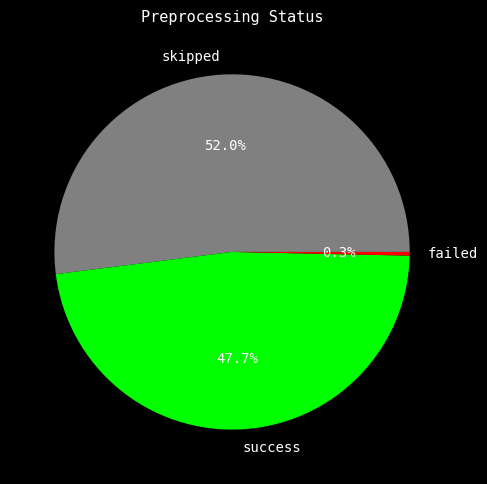

In [17]:
if LOG_PATH.exists():
    df_log = pd.read_csv(LOG_PATH)

    print("=" * 60)
    print("  PREPROCESSING LOG SUMMARY")
    print("=" * 60)
    print(f"  Total entries : {len(df_log)}")
    print()
    print("  Status breakdown:")
    for status, cnt in df_log["status"].value_counts().items():
        pct = 100 * cnt / len(df_log)
        print(f"    {status:10s}: {cnt:5d}  ({pct:.1f}%)")
    print()

    if "time_s" in df_log.columns:
        done = df_log[df_log["status"].isin(["success", "partial"])]
        if len(done) > 0:
            avg_t = done["time_s"].mean()
            remaining = len(df_batch) - len(df_log)
            eta_h = (avg_t * remaining) / 3600
            print(f"  Avg time/visit : {avg_t:.1f}s")
            print(f"  Remaining      : ~{remaining:,} visits")
            print(f"  ETA            : ~{eta_h:.1f} hours")
            print()

    if "error_msg" in df_log.columns:
        errors = df_log[df_log["status"] == "failed"]
        if len(errors) > 0:
            print(f"  ⚠️  Failed visits ({len(errors)}):")
            for _, e in errors.head(5).iterrows():
                print(f"    {e['patient_id']} | {e['visit_date']} | {e['error_msg'][:60]}")
        else:
            print("  ✅  No failed visits")

    print("=" * 60)

    # Plot status pie chart
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    colors = {"success": "lime", "skipped": "gray", "partial": "orange", "failed": "red"}
    counts = df_log["status"].value_counts()
    wedge_colors = [colors.get(s, "white") for s in counts.index]
    ax.pie(counts.values, labels=counts.index, colors=wedge_colors,
           autopct="%1.1f%%", textprops={"color": "white"})
    ax.set_title("Preprocessing Status", color="white")
    plt.tight_layout()
    plt.show()
else:
    print("No log file yet — run the batch cell first.")